# Systematic Trading Strategies with Machine Learning  
## Coursework Project – Meta-Labeling for Trading Signal Filtering

---

# 1. Project Overview

The objective of this project is to build a **metamodel** on top of a provided primary trading signal across futures contracts from multiple asset classes.

The primary model generates daily trading signals in \(\{-1,0,+1\}\):
- \(+1\): long signal
- \(-1\): short signal
- \(0\): no position

Our goal is **not** to predict returns directly.  
Instead, we aim to estimate the probability that a given primary signal is worth taking under a triple-barrier labeling framework.

More formally, we seek to model:

\[
P(\text{Trade is profitable} \mid \text{Features})
\]

using machine learning techniques.

---

# 2. Project Pipeline

The project is structured into the following stages:

## Phase 1 — Data Preparation and Exploration
- Load and clean OHLCV data
- Load and align primary signals
- Verify data integrity and temporal consistency
- Explore the characteristics of each asset class

## Phase 2 — Feature Engineering
Construction of predictive features from market data, including:
- Technical indicators
- Volatility and momentum features
- Cross-sectional features
- Latent regime features (HMM/GMM)
- Additional engineered features

## Phase 3 — Triple-Barrier Labeling
Implementation of the triple-barrier method to define supervised learning targets:
- Profit-taking barrier
- Stop-loss barrier
- Maximum holding period

We will justify all parameter choices economically and statistically.

## Phase 4 — Model Development
We will compare several model families:
- Linear models
- Tree-based ensemble methods
- Neural networks

Hyperparameter tuning and robust validation procedures will be applied.

## Phase 5 — Feature Importance Analysis
We will study:
- Individual feature importance
- Cluster-level feature importance
- SHAP/permutation-based interpretability

## Phase 6 — Out-of-Sample Evaluation
Evaluation on a clean out-of-sample period using:
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion matrices
- Comparison against the raw primary signal

## Optional Phase 7 — Strategy Construction
(Optional competition track)

Construction of a position-sizing strategy using metamodel probabilities.

---

# 3. Methodological Principles

Throughout the project, particular attention will be paid to:
- Avoiding look-ahead bias
- Preventing data leakage
- Using time-aware validation procedures
- Ensuring reproducibility
- Maintaining economic interpretability of results

The emphasis of this coursework is placed on:
- methodological rigor,
- feature engineering quality,
- validation protocol,
- and critical analysis of results.

---

# 4. Asset Universe

The project covers futures contracts from three asset classes:

## Equity Index Futures
- ES1S — S&P 500
- NQ1S — Nasdaq 100
- FESX1S — Euro Stoxx 50

## Energy
- CL1S — WTI Crude Oil
- HO1S — Heating Oil
- RB1S — RBOB Gasoline
- NG1S — Natural Gas

## Metals
- GC1S — Gold
- SI1S — Silver
- HG1S — Copper
- PL1S — Platinum

---

# 5. Initial Setup

We begin by importing the required libraries and loading the datasets.

# Phase 1 — Data Preparation and Initial Exploration

In this first phase, we prepare the raw datasets for the meta-labeling pipeline.

We focus initially on the **Energy** asset class:

| Ticker | Commodity |
|---|---|
| CL1S | WTI Crude Oil |
| HO1S | Heating Oil |
| RB1S | RBOB Gasoline |
| NG1S | Natural Gas |

The objectives of this phase are:

1. Load the OHLCV dataset and the primary signals dataset.
2. Standardize dates, instrument names, and column formats.
3. Filter the universe to Energy instruments only.
4. Align market data and primary signals on a common trading calendar.
5. Perform basic data integrity checks:
   - missing values,
   - duplicated rows,
   - date coverage,
   - signal distribution,
   - price and volume sanity checks.
6. Prepare a clean base dataframe that will later be used for feature engineering and triple-barrier labeling.

At this stage, we do **not** create labels yet.  
The purpose is to build a clean, reliable data foundation before moving to feature engineering.

In [87]:
# ============================================================
# Phase 1 — Setup and Data Loading
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Display options
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

# ------------------------------------------------------------
# Project configuration
# ------------------------------------------------------------

DATA_DIR = "."  # Change this path if your CSV files are in another folder

OHLCV_FILE = os.path.join(DATA_DIR, "ohlcv_data.csv")
SIGNALS_FILE = os.path.join(DATA_DIR, "primary_signals.csv")

ENERGY_INSTRUMENTS = ["cl1s", "ho1s", "rb1s", "ng1s"]

INSTRUMENT_NAMES = {
    "cl1s": "WTI Crude Oil",
    "ho1s": "Heating Oil",
    "rb1s": "RBOB Gasoline",
    "ng1s": "Natural Gas",
}

print("Energy universe:")
for ticker, name in INSTRUMENT_NAMES.items():
    print(f"- {ticker.upper()}: {name}")

Energy universe:
- CL1S: WTI Crude Oil
- HO1S: Heating Oil
- RB1S: RBOB Gasoline
- NG1S: Natural Gas


In [88]:
# ============================================================
# Load Raw Data
# ============================================================

ohlcv_raw = pd.read_csv(OHLCV_FILE)
signals_raw = pd.read_csv(SIGNALS_FILE)

print("OHLCV shape:", ohlcv_raw.shape)
print("Signals shape:", signals_raw.shape)

display(ohlcv_raw.head())
display(signals_raw.head())

OHLCV shape: (83547, 8)
Signals shape: (645, 12)


,date,instrument,open,high,low,close,volume,open_interest
0,1990-01-02,cl1s,21.8000,22.920,21.7900,22.8900,22868.0,66308.0
1,1990-01-02,gc1s,401.0000,404.600,400.2000,402.1000,20747.0,68855.0
2,1990-01-02,hg1s,1.0470,1.064,1.0430,1.0620,3325.0,19735.0
3,1990-01-02,ho1s,0.7475,0.776,0.7415,0.7739,20280.0,33732.0
4,1990-01-02,pl1s,484.0000,485.000,479.5000,482.2000,4561.0,13256.0


,date,es1s,nq1s,fesx1s,cl1s,ho1s,rb1s,ng1s,gc1s,si1s,hg1s,pl1s
0,2020-01-03,1,1,-1,0,0,1,0,0,1,1,-1
1,2020-01-06,1,-1,1,0,0,1,0,0,1,1,1
2,2020-01-07,1,-1,1,-1,0,-1,0,0,1,1,1
3,2020-01-08,1,1,1,0,0,1,0,0,1,1,1
4,2020-01-09,1,-1,-1,0,0,1,0,0,1,1,1


## 1.1 Initial Data Standardization

We now standardize the two datasets:

- convert dates to `datetime`,
- convert instrument names to lowercase,
- sort observations chronologically,
- filter the OHLCV data and primary signals to the Energy instruments only.

This ensures that both datasets use the same naming convention and can later be merged safely.

In [89]:
# ============================================================
# Standardize Dates and Instrument Names
# ============================================================

ohlcv = ohlcv_raw.copy()
signals = signals_raw.copy()

# Convert date columns
ohlcv["date"] = pd.to_datetime(ohlcv["date"])
signals["date"] = pd.to_datetime(signals["date"])

# Standardize instrument names
ohlcv["instrument"] = ohlcv["instrument"].str.lower()

# Keep only Energy instruments
ohlcv_energy = ohlcv[ohlcv["instrument"].isin(ENERGY_INSTRUMENTS)].copy()

# Keep date + Energy signal columns
signals_energy = signals[["date"] + ENERGY_INSTRUMENTS].copy()

# Sort
ohlcv_energy = ohlcv_energy.sort_values(["instrument", "date"]).reset_index(drop=True)
signals_energy = signals_energy.sort_values("date").reset_index(drop=True)

print("Energy OHLCV shape:", ohlcv_energy.shape)
print("Energy signals shape:", signals_energy.shape)

display(ohlcv_energy.head())
display(signals_energy.head())

Energy OHLCV shape: (32614, 8)
Energy signals shape: (645, 5)


,date,instrument,open,high,low,close,volume,open_interest
0,1990-01-02,cl1s,21.80,22.92,21.79,22.89,22868.0,66308.0
1,1990-01-03,cl1s,23.20,23.80,23.00,23.68,45177.0,61428.0
2,1990-01-04,cl1s,23.88,23.92,22.83,23.41,50061.0,60995.0
3,1990-01-05,cl1s,23.42,23.70,23.03,23.08,53070.0,57258.0
4,1990-01-08,cl1s,22.60,22.60,21.55,21.62,39720.0,54644.0


,date,cl1s,ho1s,rb1s,ng1s
0,2020-01-03,0,0,1,0
1,2020-01-06,0,0,1,0
2,2020-01-07,-1,0,-1,0
3,2020-01-08,0,0,1,0
4,2020-01-09,0,0,1,0


## 1.2 Data Integrity Checks

Before creating features or labels, we first verify the quality of the raw Energy datasets.

We check:
- date coverage by instrument,
- duplicated observations,
- missing values,
- OHLCV consistency,
- and primary signal distributions.

These checks are important because any data issue at this stage could later create misleading labels, feature leakage, or incorrect model evaluation.

In [90]:
# ============================================================
# Basic Data Integrity Checks
# ============================================================

print("OHLCV date range by instrument:")
display(
    ohlcv_energy
    .groupby("instrument")["date"]
    .agg(["min", "max", "count"])
)

print("\nSignals date range:")
display(
    signals_energy["date"].agg(["min", "max", "count"])
)

print("\nDuplicate OHLCV rows by (date, instrument):")
n_dup_ohlcv = ohlcv_energy.duplicated(subset=["date", "instrument"]).sum()
print(n_dup_ohlcv)

print("\nDuplicate signal dates:")
n_dup_signals = signals_energy.duplicated(subset=["date"]).sum()
print(n_dup_signals)

print("\nMissing values in OHLCV:")
display(ohlcv_energy.isna().sum())

print("\nMissing values in signals:")
display(signals_energy.isna().sum())

OHLCV date range by instrument:


,min,max,count
instrument,,,
cl1s,1990-01-02,2022-06-30,8171
ho1s,1990-01-02,2022-06-30,8169
ng1s,1990-04-04,2022-06-30,8104
rb1s,1990-01-02,2022-06-30,8170



Signals date range:


min      2020-01-03 00:00:00
max      2022-06-30 00:00:00
count                    645
Name: date, dtype: object


Duplicate OHLCV rows by (date, instrument):
0

Duplicate signal dates:
0

Missing values in OHLCV:


date             0
instrument       0
open             0
high             0
low              0
close            0
volume           0
open_interest    0
dtype: int64


Missing values in signals:


date    0
cl1s    0
ho1s    0
rb1s    0
ng1s    0
dtype: int64

## 1.3 Signal Distribution Analysis

Before building labels or training models, we inspect the distribution of the primary signals.

This is important because:
- the dataset may be imbalanced,
- some instruments may trade much more frequently than others,
- and the proportion of long/short/flat signals may affect both labeling and model performance.

We therefore compute the distribution of:
- long signals (+1),
- short signals (-1),
- and inactive periods (0),
for each Energy instrument.

In [91]:
# ============================================================
# Signal Distribution
# ============================================================

signal_distribution = {}

for inst in ENERGY_INSTRUMENTS:
    
    counts = (
        signals_energy[inst]
        .value_counts()
        .sort_index()
    )
    
    signal_distribution[inst] = counts

    print(f"\n{inst.upper()} signal distribution:")
    print(counts)

    print("\nPercentages:")
    print((counts / counts.sum() * 100).round(2))


CL1S signal distribution:
cl1s
-1     36
 0    223
 1    386
Name: count, dtype: int64

Percentages:
cl1s
-1     5.58
 0    34.57
 1    59.84
Name: count, dtype: float64

HO1S signal distribution:
ho1s
-1     10
 0    582
 1     53
Name: count, dtype: int64

Percentages:
ho1s
-1     1.55
 0    90.23
 1     8.22
Name: count, dtype: float64

RB1S signal distribution:
rb1s
-1    261
 0     17
 1    367
Name: count, dtype: int64

Percentages:
rb1s
-1    40.47
 0     2.64
 1    56.90
Name: count, dtype: float64

NG1S signal distribution:
ng1s
-1    124
 0    521
Name: count, dtype: int64

Percentages:
ng1s
-1    19.22
 0    80.78
Name: count, dtype: float64


## 1.4 OHLC Consistency Checks

We now perform several sanity checks on the OHLC data.

For each observation, financial market conventions imply:


$\text{low} \leq \text{open, close} \leq \text{high}$


Violations of these inequalities may indicate:
- corrupted observations,
- bad data adjustments,
- or preprocessing issues.

We also verify that prices and trading activity remain strictly positive.

In [92]:
# ============================================================
# OHLC Consistency Checks
# ============================================================

# High should be >= low
invalid_high_low = (ohlcv_energy["high"] < ohlcv_energy["low"]).sum()

# Open should lie inside [low, high]
invalid_open = (
    (ohlcv_energy["open"] < ohlcv_energy["low"]) |
    (ohlcv_energy["open"] > ohlcv_energy["high"])
).sum()

# Close should lie inside [low, high]
invalid_close = (
    (ohlcv_energy["close"] < ohlcv_energy["low"]) |
    (ohlcv_energy["close"] > ohlcv_energy["high"])
).sum()

# Negative or zero prices
non_positive_prices = (
    (ohlcv_energy[["open", "high", "low", "close"]] <= 0)
    .sum()
    .sum()
)

print("Invalid high/low rows:", invalid_high_low)
print("Invalid open rows:", invalid_open)
print("Invalid close rows:", invalid_close)
print("Non-positive prices:", non_positive_prices)

Invalid high/low rows: 0
Invalid open rows: 0
Invalid close rows: 0
Non-positive prices: 0


## 1.5 Price Series Visualization

We now visualize the historical closing prices of the Energy futures contracts.

The objective is not yet predictive modeling, but rather:
- understanding the long-term behavior of each market,
- identifying volatility regimes,
- detecting structural breaks and crises,
- and building intuition about the data before feature engineering.

Since commodity futures can exhibit very different scales and volatility levels, each instrument is plotted separately.

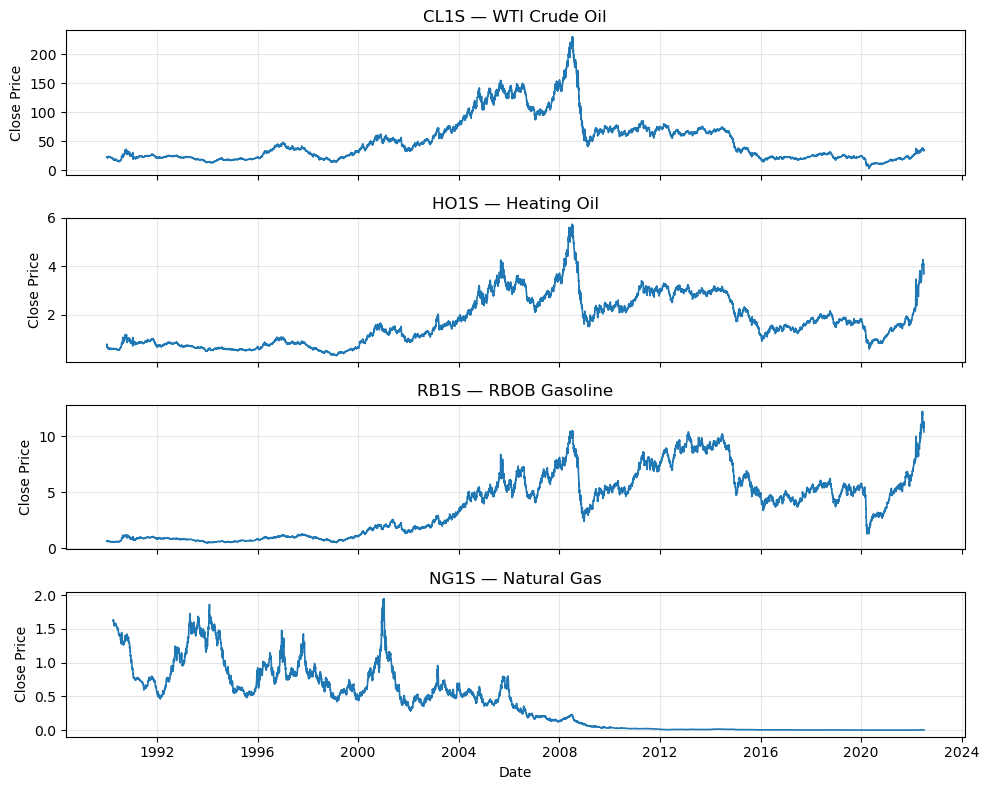

In [93]:
# ============================================================
# Historical Price Visualization
# ============================================================

fig, axes = plt.subplots(
    nrows=4,
    ncols=1,
    figsize=(10, 8),
    sharex=True
)

for ax, inst in zip(axes, ENERGY_INSTRUMENTS):

    df_inst = ohlcv_energy[
        ohlcv_energy["instrument"] == inst
    ]

    ax.plot(
        df_inst["date"],
        df_inst["close"],
        linewidth=1.2
    )

    ax.set_title(
        f"{inst.upper()} — {INSTRUMENT_NAMES[inst]}",
        fontsize=12
    )

    ax.set_ylabel("Close Price")

    ax.grid(True, alpha=0.3)

plt.xlabel("Date")
plt.tight_layout()
plt.show()

## 1.6 Return Series Construction

Financial machine learning models are generally built on returns rather than raw price levels.

We therefore compute daily log returns for each instrument:

$$
r_t = \log\left(\frac{P_t}{P_{t-1}}\right)
$$

Log returns are preferred because:
- they are additive through time,
- more statistically stable than prices,
- and largely invariant to the absolute price scale.

This is particularly important for futures contracts, where continuous-contract adjustments may distort long-term price levels.

In [94]:
# ============================================================
# Daily Log Returns
# ============================================================

ohlcv_energy["log_return"] = (
    ohlcv_energy
    .groupby("instrument")["close"]
    .transform(lambda x: np.log(x / x.shift(1)))
)

display(
    ohlcv_energy[
        ["date", "instrument", "close", "log_return"]
    ].head(10)
)

,date,instrument,close,log_return
0,1990-01-02,cl1s,22.89,NaN
1,1990-01-03,cl1s,23.68,0.033931
2,1990-01-04,cl1s,23.41,-0.011468
3,1990-01-05,cl1s,23.08,-0.014197
4,1990-01-08,cl1s,21.62,-0.065348
5,1990-01-09,cl1s,22.07,0.020600
6,1990-01-10,cl1s,22.90,0.036918
7,1990-01-11,cl1s,23.14,0.010426
8,1990-01-12,cl1s,23.13,-0.000432
9,1990-01-15,cl1s,22.36,-0.033857


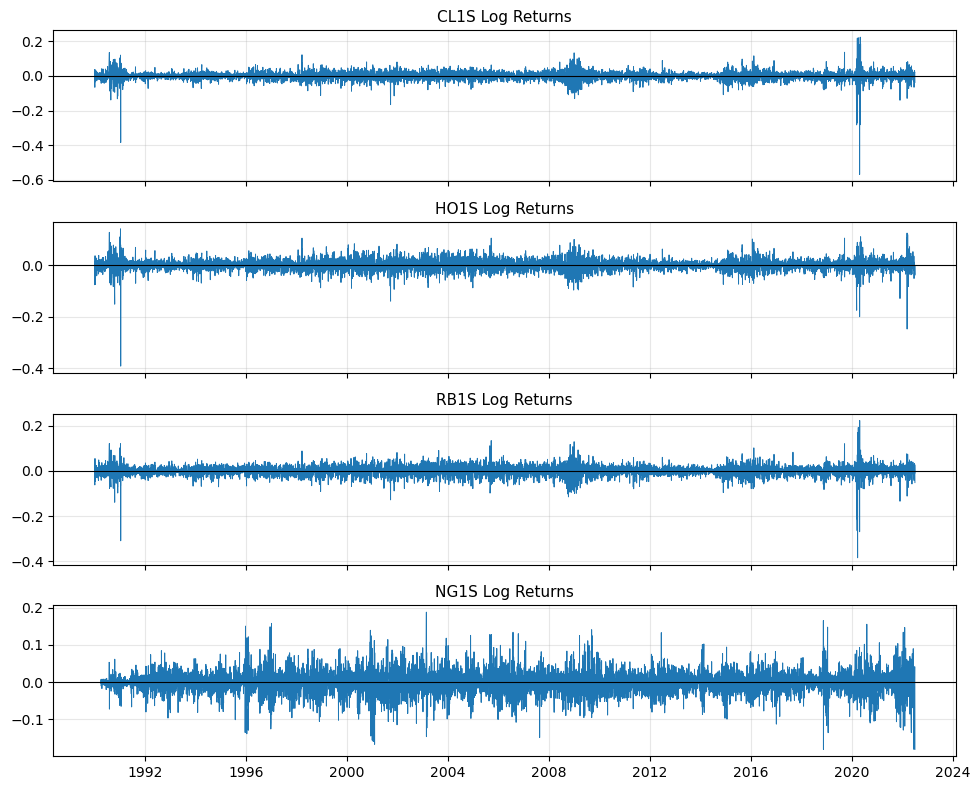

In [95]:
# ============================================================
# Log Return Visualization
# ============================================================

fig, axes = plt.subplots(
    nrows=4,
    ncols=1,
    figsize=(10, 8),
    sharex=True
)

for ax, inst in zip(axes, ENERGY_INSTRUMENTS):

    df_inst = ohlcv_energy[
        ohlcv_energy["instrument"] == inst
    ]

    ax.plot(
        df_inst["date"],
        df_inst["log_return"],
        linewidth=0.7
    )

    ax.set_title(
        f"{inst.upper()} Log Returns",
        fontsize=11
    )

    ax.axhline(0, color="black", linewidth=0.8)

    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 1.7 Reshaping Primary Signals

The primary signal dataset is currently stored in a wide format:

| date | cl1s | ho1s | rb1s | ng1s |
|---|---|---|---|---|

However, the OHLCV dataset is stored in long format:

| date | instrument | open | high | low | close | ... |

To simplify merging and downstream processing, we reshape the signal dataset into long format using `pandas.melt()`.

The resulting structure becomes:

| date | instrument | signal |
|---|---|---|

This representation is much more convenient for:
- feature engineering,
- labeling,
- merging datasets,
- and machine learning pipelines.

In [96]:
# ============================================================
# Reshape Signals to Long Format
# ============================================================

signals_long = signals_energy.melt(
    id_vars="date",
    value_vars=ENERGY_INSTRUMENTS,
    var_name="instrument",
    value_name="primary_signal"
)

signals_long = (
    signals_long
    .sort_values(["instrument", "date"])
    .reset_index(drop=True)
)

print("Signals long shape:", signals_long.shape)

display(signals_long.head(10))

Signals long shape: (2580, 3)


,date,instrument,primary_signal
0,2020-01-03,cl1s,0
1,2020-01-06,cl1s,0
2,2020-01-07,cl1s,-1
3,2020-01-08,cl1s,0
4,2020-01-09,cl1s,0
5,2020-01-10,cl1s,0
6,2020-01-13,cl1s,0
7,2020-01-14,cl1s,0
8,2020-01-15,cl1s,0
9,2020-01-16,cl1s,0


# Phase 2 — Feature Engineering

In this phase, we construct predictive features from the Energy OHLCV dataset.

The objective is to describe the market environment in which each primary signal occurs.  
These features will later be used by the metamodel to estimate whether a given primary trading signal is worth taking.

We construct features separately for each instrument, using only past and current information available at each date.  
This is essential to avoid look-ahead bias.

The feature engineering process is organized into several blocks:

1. **Core return and momentum features**
   - daily returns,
   - rolling cumulative returns,
   - short-term and medium-term momentum.

2. **Volatility features**
   - rolling realized volatility,
   - volatility ratios,
   - volatility regime indicators.

3. **Volume and open-interest features**
   - volume changes,
   - volume z-scores,
   - open-interest changes.

4. **Technical indicators**
   - RSI,
   - MACD,
   - Bollinger-style z-scores.

5. **Time-series dependence features**
   - rolling autocorrelation,
   - volatility clustering proxies,
   - trend persistence measures.

6. **Cross-sectional features**
   - relative momentum,
   - relative volatility,
   - ranks within the Energy asset class.

7. **Latent regime features**
   - GMM/HMM-based regime probabilities,
   - market turbulence indicators.

At this stage, we start with a robust set of core statistical features before adding more advanced indicators.

## 2.1 Core Return and Momentum Features

We begin with a set of core return-based and momentum features.

Momentum features aim to capture whether an instrument has recently experienced persistent positive or negative price movements.  
Such features are widely used in systematic trading strategies, where trend-following and persistence effects often play an important role.

For each instrument, we compute rolling momentum over several horizons:

$$
\text{mom}_{k,t}
=
\log\left(\frac{P_t}{P_{t-k}}\right)
$$

where:
- \(P_t\) is the closing price at time \(t\),
- and \(k\) represents the lookback horizon.

We use multiple horizons in order to capture:
- short-term momentum,
- medium-term trends,
- and longer-term price persistence.

In addition, we compute rolling average returns:

$$
\bar r_t^{(k)}
=
\frac{1}{k}
\sum_{i=0}^{k-1} r_{t-i}
$$

which provide smoother estimates of recent market direction and local return persistence.

All features are computed independently for each instrument using:

```python
groupby("instrument")

In [97]:
# ============================================================
# Phase 2 — Feature Engineering Setup
# ============================================================

features_df = ohlcv_energy.copy()

# Make sure data is sorted before computing rolling/grouped features
features_df = (
    features_df
    .sort_values(["instrument", "date"])
    .reset_index(drop=True)
)

print("Feature engineering base shape:", features_df.shape)
display(features_df.head())

Feature engineering base shape: (32614, 9)


,date,instrument,open,high,low,close,volume,open_interest,log_return
0,1990-01-02,cl1s,21.80,22.92,21.79,22.89,22868.0,66308.0,NaN
1,1990-01-03,cl1s,23.20,23.80,23.00,23.68,45177.0,61428.0,0.033931
2,1990-01-04,cl1s,23.88,23.92,22.83,23.41,50061.0,60995.0,-0.011468
3,1990-01-05,cl1s,23.42,23.70,23.03,23.08,53070.0,57258.0,-0.014197
4,1990-01-08,cl1s,22.60,22.60,21.55,21.62,39720.0,54644.0,-0.065348


In [98]:
# ============================================================
# Core Return and Momentum Features
# ============================================================

MOMENTUM_WINDOWS = [5, 10, 20, 60]

for window in MOMENTUM_WINDOWS:
    
    features_df[f"momentum_{window}d"] = (
        features_df
        .groupby("instrument")["close"]
        .transform(lambda x: np.log(x / x.shift(window)))
    )

# Rolling mean return features
RETURN_MEAN_WINDOWS = [5, 20, 60]

for window in RETURN_MEAN_WINDOWS:
    
    features_df[f"mean_return_{window}d"] = (
        features_df
        .groupby("instrument")["log_return"]
        .transform(lambda x: x.rolling(window=window).mean())
    )

display(
    features_df[
        ["date", "instrument", "close", "log_return",
         "momentum_5d", "momentum_20d", "momentum_60d",
         "mean_return_5d", "mean_return_20d"]
    ].head(25)
)

,date,instrument,close,log_return,momentum_5d,momentum_20d,momentum_60d,mean_return_5d,mean_return_20d
0,1990-01-02,cl1s,22.890000,NaN,NaN,NaN,NaN,NaN,NaN
1,1990-01-03,cl1s,23.680000,0.033931,NaN,NaN,NaN,NaN,NaN
2,1990-01-04,cl1s,23.410000,-0.011468,NaN,NaN,NaN,NaN,NaN
3,1990-01-05,cl1s,23.080000,-0.014197,NaN,NaN,NaN,NaN,NaN
4,1990-01-08,cl1s,21.620000,-0.065348,NaN,NaN,NaN,NaN,NaN
5,1990-01-09,cl1s,22.070000,0.020600,-0.036481,NaN,NaN,-0.007296,NaN
6,1990-01-10,cl1s,22.900000,0.036918,-0.033494,NaN,NaN,-0.006699,NaN
7,1990-01-11,cl1s,23.140000,0.010426,-0.011601,NaN,NaN,-0.002320,NaN
8,1990-01-12,cl1s,23.130000,-0.000432,0.002164,NaN,NaN,0.000433,NaN
9,1990-01-15,cl1s,22.360000,-0.033857,0.033655,NaN,NaN,0.006731,NaN


## 2.2 Volatility Features

Volatility is one of the most important variables in financial markets, especially for commodities and futures contracts.

Periods of high volatility often correspond to:
- market stress,
- regime shifts,
- liquidity shocks,
- or macroeconomic uncertainty.

We therefore construct several volatility-related features.

### Rolling Realized Volatility

We first compute rolling realized volatility using the standard deviation of daily log returns:

$$
\sigma_t^{(k)}
=
\sqrt{
\frac{1}{k-1}
\sum_{i=0}^{k-1}
(r_{t-i} - \bar r_t)^2
}
$$

over multiple horizons.

### EWMA Volatility

We also compute exponentially weighted volatility estimates, which react faster to recent market shocks.

### Volatility Ratios

Finally, we compute volatility ratios such as:

$$
\frac{\sigma_{20}}{\sigma_{60}}
$$

to detect volatility regime changes and volatility expansions.

In [99]:
# ============================================================
# Rolling Realized Volatility
# ============================================================

VOL_WINDOWS = [5, 20, 60]

for window in VOL_WINDOWS:

    features_df[f"realized_vol_{window}d"] = (
        features_df
        .groupby("instrument")["log_return"]
        .transform(lambda x: x.rolling(window=window).std())
    )

display(
    features_df[
        [
            "date",
            "instrument",
            "log_return",
            "realized_vol_5d",
            "realized_vol_20d",
            "realized_vol_60d"
        ]
    ].head() #change to head(30) if you want to see more rows
)

,date,instrument,log_return,realized_vol_5d,realized_vol_20d,realized_vol_60d
0,1990-01-02,cl1s,NaN,NaN,NaN,NaN
1,1990-01-03,cl1s,0.033931,NaN,NaN,NaN
2,1990-01-04,cl1s,-0.011468,NaN,NaN,NaN
3,1990-01-05,cl1s,-0.014197,NaN,NaN,NaN
4,1990-01-08,cl1s,-0.065348,NaN,NaN,NaN


In [100]:
# ============================================================
# EWMA Volatility
# ============================================================

EWMA_SPANS = [10, 20]

for span in EWMA_SPANS:

    features_df[f"ewma_vol_{span}d"] = (
        features_df
        .groupby("instrument")["log_return"]
        .transform(
            lambda x: x.ewm(span=span, adjust=False).std()
        )
    )

display(
    features_df[
        [
            "date",
            "instrument",
            "ewma_vol_10d",
            "ewma_vol_20d"
        ]
    ].head() #change to head(30) if you want to see more rows
)

,date,instrument,ewma_vol_10d,ewma_vol_20d
0,1990-01-02,cl1s,NaN,NaN
1,1990-01-03,cl1s,NaN,NaN
2,1990-01-04,cl1s,0.032101,0.032101
3,1990-01-05,cl1s,0.031324,0.032253
4,1990-01-08,cl1s,0.047855,0.048410


In [101]:
# ============================================================
# Volatility Regime Features
# ============================================================

features_df["vol_ratio_20_60"] = (
    features_df["realized_vol_20d"]
    /
    features_df["realized_vol_60d"]
)

display(
    features_df[
        [
            "date",
            "instrument",
            "realized_vol_20d",
            "realized_vol_60d",
            "vol_ratio_20_60"
        ]
    ].head() #change to head(30) if you want to see more rows
)

,date,instrument,realized_vol_20d,realized_vol_60d,vol_ratio_20_60
0,1990-01-02,cl1s,NaN,NaN,NaN
1,1990-01-03,cl1s,NaN,NaN,NaN
2,1990-01-04,cl1s,NaN,NaN,NaN
3,1990-01-05,cl1s,NaN,NaN,NaN
4,1990-01-08,cl1s,NaN,NaN,NaN


## 2.3 Volume and Open Interest Features

Futures markets contain additional information beyond prices alone.

In particular:
- trading volume,
- and open interest

can provide insight into:
- market participation,
- liquidity conditions,
- trend confirmation,
- and abnormal trading activity.

We therefore construct several features based on:
- volume dynamics,
- abnormal volume detection,
- and changes in open interest.

### Volume Z-Scores

We compute rolling z-scores of volume:

$$
z_t^{vol}
=
\frac{V_t - \mu_t^{(k)}}{\sigma_t^{(k)}}
$$

to detect unusually high or low trading activity.

### Open Interest Changes

We also compute changes in open interest, which may help identify:
- trend strengthening,
- position buildup,
- or liquidation regimes.

All features are computed independently for each instrument.

In [102]:
# ============================================================
# Volume Features
# ============================================================

# Log volume change
features_df["log_volume_change"] = (
    features_df
    .groupby("instrument")["volume"]
    .transform(lambda x: np.log(x / x.shift(1)))
)

# Rolling volume averages
VOLUME_WINDOWS = [5, 20]

for window in VOLUME_WINDOWS:

    features_df[f"volume_mean_{window}d"] = (
        features_df
        .groupby("instrument")["volume"]
        .transform(lambda x: x.rolling(window).mean())
    )

    features_df[f"volume_std_{window}d"] = (
        features_df
        .groupby("instrument")["volume"]
        .transform(lambda x: x.rolling(window).std())
    )

display(
    features_df[
        [
            "date",
            "instrument",
            "volume",
            "log_volume_change",
            "volume_mean_20d",
            "volume_std_20d"
        ]
    ].head() #change to head(30) if you want to see more rows
)

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,date,instrument,volume,log_volume_change,volume_mean_20d,volume_std_20d
0,1990-01-02,cl1s,22868.0,NaN,NaN,NaN
1,1990-01-03,cl1s,45177.0,0.680850,NaN,NaN
2,1990-01-04,cl1s,50061.0,0.102654,NaN,NaN
3,1990-01-05,cl1s,53070.0,0.058370,NaN,NaN
4,1990-01-08,cl1s,39720.0,-0.289757,NaN,NaN


In [103]:
# ============================================================
# Volume Z-Score Features
# ============================================================

features_df["volume_zscore_20d"] = (
    (
        features_df["volume"]
        - features_df["volume_mean_20d"]
    )
    /
    features_df["volume_std_20d"]
)

display(
    features_df[
        [
            "date",
            "instrument",
            "volume",
            "volume_mean_20d",
            "volume_std_20d",
            "volume_zscore_20d"
        ]
    ].head() #change to head(30) if you want to see more rows
)

,date,instrument,volume,volume_mean_20d,volume_std_20d,volume_zscore_20d
0,1990-01-02,cl1s,22868.0,NaN,NaN,NaN
1,1990-01-03,cl1s,45177.0,NaN,NaN,NaN
2,1990-01-04,cl1s,50061.0,NaN,NaN,NaN
3,1990-01-05,cl1s,53070.0,NaN,NaN,NaN
4,1990-01-08,cl1s,39720.0,NaN,NaN,NaN


In [104]:
# ============================================================
# Open Interest Features
# ============================================================

# Log change in open interest
features_df["log_oi_change"] = (
    features_df
    .groupby("instrument")["open_interest"]
    .transform(lambda x: np.log(x / x.shift(1)))
)

# Open interest momentum
OI_WINDOWS = [5, 20]

for window in OI_WINDOWS:

    features_df[f"oi_momentum_{window}d"] = (
        features_df
        .groupby("instrument")["open_interest"]
        .transform(lambda x: np.log(x / x.shift(window)))
    )

display(
    features_df[
        [
            "date",
            "instrument",
            "open_interest",
            "log_oi_change",
            "oi_momentum_5d",
            "oi_momentum_20d"
        ]
    ].head() #change to head(30) if you want to see more rows
)

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,date,instrument,open_interest,log_oi_change,oi_momentum_5d,oi_momentum_20d
0,1990-01-02,cl1s,66308.0,NaN,NaN,NaN
1,1990-01-03,cl1s,61428.0,-0.076445,NaN,NaN
2,1990-01-04,cl1s,60995.0,-0.007074,NaN,NaN
3,1990-01-05,cl1s,57258.0,-0.063225,NaN,NaN
4,1990-01-08,cl1s,54644.0,-0.046728,NaN,NaN


## 2.4 Technical Indicators

We now construct a set of classical technical indicators.

These indicators are widely used in systematic trading because they summarize different aspects of recent price dynamics:

- **RSI** captures overbought and oversold conditions.
- **Bollinger z-scores** measure how far the current price is from its recent moving average.
- **MACD** captures trend strength through the difference between short-term and long-term exponential moving averages.

Although these indicators are simple, they provide interpretable signals that can help the metamodel identify market environments where the primary signal is more or less reliable.

In [105]:
# ============================================================
# RSI Indicator
# ============================================================

def compute_rsi(series, window=14):
    """
    Compute the Relative Strength Index (RSI).
    """
    delta = series.diff()

    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))

    return rsi


features_df["rsi_14d"] = (
    features_df
    .groupby("instrument")["close"]
    .transform(lambda x: compute_rsi(x, window=14))
)

display(
    features_df[
        ["date", "instrument", "close", "rsi_14d"]
    ].head(70)
)

,date,instrument,close,rsi_14d
0,1990-01-02,cl1s,22.890000,NaN
1,1990-01-03,cl1s,23.680000,NaN
2,1990-01-04,cl1s,23.410000,NaN
3,1990-01-05,cl1s,23.080000,NaN
4,1990-01-08,cl1s,21.620000,NaN
...,...,...,...,...
65,1990-04-04,cl1s,20.535266,36.024845
66,1990-04-05,cl1s,20.171901,35.474006
67,1990-04-06,cl1s,19.881210,37.060703
68,1990-04-09,cl1s,19.144100,31.780822


In [106]:
# ============================================================
# Bollinger-Style Price Z-Score
# ============================================================

BOLLINGER_WINDOWS = [20, 60]

for window in BOLLINGER_WINDOWS:

    rolling_mean = (
        features_df
        .groupby("instrument")["close"]
        .transform(lambda x: x.rolling(window=window).mean())
    )

    rolling_std = (
        features_df
        .groupby("instrument")["close"]
        .transform(lambda x: x.rolling(window=window).std())
    )

    features_df[f"price_zscore_{window}d"] = (
        (features_df["close"] - rolling_mean) / rolling_std
    )

display(
    features_df[
        [
            "date",
            "instrument",
            "close",
            "price_zscore_20d",
            "price_zscore_60d"
        ]
    ].head(70)
)

,date,instrument,close,price_zscore_20d,price_zscore_60d
0,1990-01-02,cl1s,22.890000,NaN,NaN
1,1990-01-03,cl1s,23.680000,NaN,NaN
2,1990-01-04,cl1s,23.410000,NaN,NaN
3,1990-01-05,cl1s,23.080000,NaN,NaN
4,1990-01-08,cl1s,21.620000,NaN,NaN
...,...,...,...,...,...
65,1990-04-04,cl1s,20.535266,-1.594795,-1.792779
66,1990-04-05,cl1s,20.171901,-2.371197,-2.030857
67,1990-04-06,cl1s,19.881210,-2.535736,-2.170688
68,1990-04-09,cl1s,19.144100,-2.979594,-2.622275


In [107]:
# ============================================================
# MACD Indicator
# ============================================================

def compute_macd(series, short_span=12, long_span=26, signal_span=9):
    """
    Compute MACD, MACD signal line, and MACD histogram.
    """
    ema_short = series.ewm(span=short_span, adjust=False).mean()
    ema_long = series.ewm(span=long_span, adjust=False).mean()

    macd = ema_short - ema_long
    macd_signal = macd.ewm(span=signal_span, adjust=False).mean()
    macd_hist = macd - macd_signal

    return macd, macd_signal, macd_hist


macd_results = (
    features_df
    .groupby("instrument")["close"]
    .apply(lambda x: pd.DataFrame({
        "macd": compute_macd(x)[0],
        "macd_signal": compute_macd(x)[1],
        "macd_hist": compute_macd(x)[2],
    }, index=x.index))
)

macd_results = macd_results.reset_index(level=0, drop=True)

features_df[["macd", "macd_signal", "macd_hist"]] = macd_results[
    ["macd", "macd_signal", "macd_hist"]
]

display(
    features_df[
        [
            "date",
            "instrument",
            "close",
            "macd",
            "macd_signal",
            "macd_hist"
        ]
    ].head(70)
)

,date,instrument,close,macd,macd_signal,macd_hist
0,1990-01-02,cl1s,22.890000,0.000000,0.000000,0.000000
1,1990-01-03,cl1s,23.680000,0.063020,0.012604,0.050416
2,1990-01-04,cl1s,23.410000,0.090138,0.028111,0.062027
3,1990-01-05,cl1s,23.080000,0.084032,0.039295,0.044737
4,1990-01-08,cl1s,21.620000,-0.038176,0.023801,-0.061977
...,...,...,...,...,...,...
65,1990-04-04,cl1s,20.535266,-0.379125,-0.424619,0.045493
66,1990-04-05,cl1s,20.171901,-0.419359,-0.423567,0.004207
67,1990-04-06,cl1s,19.881210,-0.469292,-0.432712,-0.036580
68,1990-04-09,cl1s,19.144100,-0.561865,-0.458543,-0.103323


## 2.5 Time-Series Dependence Features

Financial time series are not independent through time.

In particular:
- returns may exhibit short-term momentum or mean reversion,
- volatility tends to cluster,
- and trends may persist for several consecutive periods.

We therefore construct features designed to capture temporal dependence structures.

### Rolling Return Autocorrelation

We compute rolling autocorrelation of returns to measure:
- short-term trend persistence,
- or mean-reversion effects.

### Absolute Return Autocorrelation

We also compute autocorrelation of absolute returns:

$$
Corr(|r_t|, |r_{t-1}|)
$$

which is a classical proxy for volatility clustering.

### Trend Persistence

Finally, we compute rolling proportions of positive-return days in order to measure the persistence of directional trends.

In [108]:
# ============================================================
# Rolling Return Autocorrelation
# ============================================================

AUTOCORR_WINDOWS = [20, 60]

for window in AUTOCORR_WINDOWS:

    features_df[f"autocorr_return_{window}d"] = (
        features_df
        .groupby("instrument")["log_return"]
        .transform(
            lambda x: x.rolling(window).corr(x.shift(1))
        )
    )

display(
    features_df[
        [
            "date",
            "instrument",
            "log_return",
            "autocorr_return_20d",
            "autocorr_return_60d"
        ]
    ].head(80)
)

,date,instrument,log_return,autocorr_return_20d,autocorr_return_60d
0,1990-01-02,cl1s,NaN,NaN,NaN
1,1990-01-03,cl1s,0.033931,NaN,NaN
2,1990-01-04,cl1s,-0.011468,NaN,NaN
3,1990-01-05,cl1s,-0.014197,NaN,NaN
4,1990-01-08,cl1s,-0.065348,NaN,NaN
...,...,...,...,...,...
75,1990-04-19,cl1s,0.042214,0.113603,0.034054
76,1990-04-20,cl1s,-0.002653,0.099340,0.033998
77,1990-04-23,cl1s,0.013196,0.084618,0.029485
78,1990-04-24,cl1s,-0.003677,0.061846,-0.010933


In [109]:
# ============================================================
# Absolute Return Autocorrelation
# ============================================================

features_df["abs_log_return"] = (
    features_df["log_return"].abs()
)

for window in AUTOCORR_WINDOWS:

    features_df[f"autocorr_abs_return_{window}d"] = (
        features_df
        .groupby("instrument")["abs_log_return"]
        .transform(
            lambda x: x.rolling(window).corr(x.shift(1))
        )
    )

display(
    features_df[
        [
            "date",
            "instrument",
            "abs_log_return",
            "autocorr_abs_return_20d",
            "autocorr_abs_return_60d"
        ]
    ].head(80)
)

,date,instrument,abs_log_return,autocorr_abs_return_20d,autocorr_abs_return_60d
0,1990-01-02,cl1s,NaN,NaN,NaN
1,1990-01-03,cl1s,0.033931,NaN,NaN
2,1990-01-04,cl1s,0.011468,NaN,NaN
3,1990-01-05,cl1s,0.014197,NaN,NaN
4,1990-01-08,cl1s,0.065348,NaN,NaN
...,...,...,...,...,...
75,1990-04-19,cl1s,0.042214,0.322005,0.141686
76,1990-04-20,cl1s,0.002653,0.131837,0.057133
77,1990-04-23,cl1s,0.013196,0.161377,0.101448
78,1990-04-24,cl1s,0.003677,0.187625,0.099012


In [110]:
# ============================================================
# Trend Persistence Features
# ============================================================

# Positive-return indicator
features_df["positive_return"] = (
    (features_df["log_return"] > 0).astype(int)
)

PERSISTENCE_WINDOWS = [10, 20]

for window in PERSISTENCE_WINDOWS:

    features_df[f"positive_return_ratio_{window}d"] = (
        features_df
        .groupby("instrument")["positive_return"]
        .transform(
            lambda x: x.rolling(window).mean()
        )
    )

display(
    features_df[
        [
            "date",
            "instrument",
            "positive_return",
            "positive_return_ratio_10d",
            "positive_return_ratio_20d"
        ]
    ].head(70)
)

,date,instrument,positive_return,positive_return_ratio_10d,positive_return_ratio_20d
0,1990-01-02,cl1s,0,NaN,NaN
1,1990-01-03,cl1s,1,NaN,NaN
2,1990-01-04,cl1s,0,NaN,NaN
3,1990-01-05,cl1s,0,NaN,NaN
4,1990-01-08,cl1s,0,NaN,NaN
...,...,...,...,...,...
65,1990-04-04,cl1s,0,0.6,0.4
66,1990-04-05,cl1s,0,0.5,0.4
67,1990-04-06,cl1s,0,0.4,0.4
68,1990-04-09,cl1s,0,0.3,0.4


## 2.6 Cross-Sectional Features

So far, all features were computed independently for each instrument through time.

We now introduce **cross-sectional features**, which compare instruments within the Energy asset class at a given date.

These features attempt to capture:
- relative strength,
- relative volatility,
- sector dispersion,
- and intra-sector positioning.

Cross-sectional information is particularly important in multi-asset systematic trading because the attractiveness of a signal may depend not only on the state of one asset, but also on its position relative to the rest of the sector.

All cross-sectional features are computed date-by-date across the Energy universe.

In [111]:
# ============================================================
# Cross-Sectional Momentum Rank
# ============================================================

features_df["momentum_rank_20d"] = (
    features_df
    .groupby("date")["momentum_20d"]
    .rank(pct=True)
)

features_df["momentum_rank_60d"] = (
    features_df
    .groupby("date")["momentum_60d"]
    .rank(pct=True)
)

display(
    features_df[
        [
            "date",
            "instrument",
            "momentum_20d",
            "momentum_rank_20d",
            "momentum_60d",
            "momentum_rank_60d"
        ]
    ]
    .sort_values(["date", "momentum_rank_20d"])
    .head(70)
)

,date,instrument,momentum_20d,momentum_rank_20d,momentum_60d,momentum_rank_60d
0,1990-01-02,cl1s,NaN,NaN,NaN,NaN
8171,1990-01-02,ho1s,NaN,NaN,NaN,NaN
24444,1990-01-02,rb1s,NaN,NaN,NaN,NaN
1,1990-01-03,cl1s,NaN,NaN,NaN,NaN
8172,1990-01-03,ho1s,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
21,1990-01-31,cl1s,0.004042,1.000000,NaN,NaN
8193,1990-02-01,ho1s,-0.216586,0.333333,NaN,NaN
24466,1990-02-01,rb1s,-0.056451,0.666667,NaN,NaN
22,1990-02-01,cl1s,0.016391,1.000000,NaN,NaN


In [112]:
# ============================================================
# Relative Volatility Features
# ============================================================

# Sector average volatility by date
sector_avg_vol_20d = (
    features_df
    .groupby("date")["realized_vol_20d"]
    .transform("mean")
)

sector_avg_vol_60d = (
    features_df
    .groupby("date")["realized_vol_60d"]
    .transform("mean")
)

# Relative volatility
features_df["relative_vol_20d"] = (
    features_df["realized_vol_20d"]
    / sector_avg_vol_20d
)

features_df["relative_vol_60d"] = (
    features_df["realized_vol_60d"]
    / sector_avg_vol_60d
)

display(
    features_df[
        [
            "date",
            "instrument",
            "realized_vol_20d",
            "relative_vol_20d",
            "realized_vol_60d",
            "relative_vol_60d"
        ]
    ].head(70)
)

,date,instrument,realized_vol_20d,relative_vol_20d,realized_vol_60d,relative_vol_60d
0,1990-01-02,cl1s,NaN,NaN,NaN,NaN
1,1990-01-03,cl1s,NaN,NaN,NaN,NaN
2,1990-01-04,cl1s,NaN,NaN,NaN,NaN
3,1990-01-05,cl1s,NaN,NaN,NaN,NaN
4,1990-01-08,cl1s,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
65,1990-04-04,cl1s,0.012938,0.923443,0.015101,0.802494
66,1990-04-05,cl1s,0.013313,0.923523,0.014396,0.795834
67,1990-04-06,cl1s,0.013197,0.953786,0.014388,0.804626
68,1990-04-09,cl1s,0.015195,1.030745,0.015087,0.830741


In [113]:
# ============================================================
# Sector Dispersion Features
# ============================================================

# Cross-sectional std of momentum across assets
features_df["sector_momentum_dispersion_20d"] = (
    features_df
    .groupby("date")["momentum_20d"]
    .transform("std")
)

features_df["sector_momentum_dispersion_60d"] = (
    features_df
    .groupby("date")["momentum_60d"]
    .transform("std")
)

# Cross-sectional std of volatility across assets
features_df["sector_vol_dispersion_20d"] = (
    features_df
    .groupby("date")["realized_vol_20d"]
    .transform("std")
)

display(
    features_df[
        [
            "date",
            "instrument",
            "sector_momentum_dispersion_20d",
            "sector_momentum_dispersion_60d",
            "sector_vol_dispersion_20d"
        ]
    ].head(70)
)

,date,instrument,sector_momentum_dispersion_20d,sector_momentum_dispersion_60d,sector_vol_dispersion_20d
0,1990-01-02,cl1s,NaN,NaN,NaN
1,1990-01-03,cl1s,NaN,NaN,NaN
2,1990-01-04,cl1s,NaN,NaN,NaN
3,1990-01-05,cl1s,NaN,NaN,NaN
4,1990-01-08,cl1s,NaN,NaN,NaN
...,...,...,...,...,...
65,1990-04-04,cl1s,0.063415,0.028504,0.001094
66,1990-04-05,cl1s,0.062656,0.009315,0.001460
67,1990-04-06,cl1s,0.068239,0.007904,0.001864
68,1990-04-09,cl1s,0.080652,0.009267,0.001917


In [114]:
# ============================================================
# Relative Momentum vs Sector Mean
# ============================================================

sector_mean_momentum_20d = (
    features_df
    .groupby("date")["momentum_20d"]
    .transform("mean")
)

features_df["relative_momentum_20d"] = (
    features_df["momentum_20d"]
    - sector_mean_momentum_20d
)

display(
    features_df[
        [
            "date",
            "instrument",
            "momentum_20d",
            "relative_momentum_20d"
        ]
    ]
    .sort_values(["date", "relative_momentum_20d"])
    .head(70)
)

,date,instrument,momentum_20d,relative_momentum_20d
0,1990-01-02,cl1s,NaN,NaN
8171,1990-01-02,ho1s,NaN,NaN
24444,1990-01-02,rb1s,NaN,NaN
1,1990-01-03,cl1s,NaN,NaN
8172,1990-01-03,ho1s,NaN,NaN
...,...,...,...,...
21,1990-01-31,cl1s,0.004042,0.121233
8193,1990-02-01,ho1s,-0.216586,-0.131037
24466,1990-02-01,rb1s,-0.056451,0.029098
22,1990-02-01,cl1s,0.016391,0.101940


## 2.7 Feature Set Summary

Before moving to latent regime features, we summarize the feature set created so far and inspect the amount of missing data generated by rolling-window calculations.

In [115]:
# ============================================================
# Feature Set Summary
# ============================================================

feature_columns = [
    col for col in features_df.columns
    if col not in [
        "date", "instrument", "open", "high", "low", "close",
        "volume", "open_interest"
    ]
]

print("Number of engineered features:", len(feature_columns))
print("\nFeature columns:")
for col in feature_columns:
    print("-", col)

missing_summary = (
    features_df[feature_columns]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .to_frame("missing_ratio")
)

display(missing_summary.head(30))

Number of engineered features: 45

Feature columns:
- log_return
- momentum_5d
- momentum_10d
- momentum_20d
- momentum_60d
- mean_return_5d
- mean_return_20d
- mean_return_60d
- realized_vol_5d
- realized_vol_20d
- realized_vol_60d
- ewma_vol_10d
- ewma_vol_20d
- vol_ratio_20_60
- log_volume_change
- volume_mean_5d
- volume_std_5d
- volume_mean_20d
- volume_std_20d
- volume_zscore_20d
- log_oi_change
- oi_momentum_5d
- oi_momentum_20d
- rsi_14d
- price_zscore_20d
- price_zscore_60d
- macd
- macd_signal
- macd_hist
- autocorr_return_20d
- autocorr_return_60d
- abs_log_return
- autocorr_abs_return_20d
- autocorr_abs_return_60d
- positive_return
- positive_return_ratio_10d
- positive_return_ratio_20d
- momentum_rank_20d
- momentum_rank_60d
- relative_vol_20d
- relative_vol_60d
- sector_momentum_dispersion_20d
- sector_momentum_dispersion_60d
- sector_vol_dispersion_20d
- relative_momentum_20d


,missing_ratio
autocorr_abs_return_60d,0.007481
autocorr_return_60d,0.007481
relative_vol_60d,0.007359
momentum_60d,0.007359
momentum_rank_60d,0.007359
mean_return_60d,0.007359
realized_vol_60d,0.007359
vol_ratio_20_60,0.007359
price_zscore_60d,0.007236
sector_momentum_dispersion_60d,0.005550


## 2.8 HMM Regime Features

We now add latent regime features using a Hidden Markov Model (HMM).

Unlike technical indicators, HMM features are not directly computed from prices. Instead, the HMM learns hidden market states from observable variables such as returns, volatility, and momentum.

To avoid look-ahead bias, the HMM will be fitted only on the training period for each instrument. The fitted model will then be used to infer regime probabilities for both the training and test periods.

In [116]:
# ============================================================
# HMM Setup
# ============================================================

try:
    from hmmlearn.hmm import GaussianHMM
    print("hmmlearn is already installed.")
except ImportError:
    print("hmmlearn is not installed. Run the next cell:")
    print("!pip install hmmlearn")

hmmlearn is already installed.


### 2.8.1 Define HMM Inputs

We use a small set of interpretable variables to train the HMM:

- daily log return,
- 20-day realized volatility,
- 20-day momentum.

These variables allow the HMM to distinguish between calm, volatile, trending, and stressed market regimes.

In [117]:
# ============================================================
# Define HMM input features
# ============================================================

HMM_FEATURES = [
    "log_return",
    "realized_vol_20d",
    "momentum_20d"
]

N_HMM_STATES = 3

print("HMM input features:", HMM_FEATURES)
print("Number of HMM regimes:", N_HMM_STATES)

HMM input features: ['log_return', 'realized_vol_20d', 'momentum_20d']
Number of HMM regimes: 3


### 2.8.2 Define Train/Test Split for HMM

Before fitting the HMM, we define a chronological train/test split using the primary signal dates.

For each instrument, the first 80% of signal dates are assigned to the training period, while the last 20% are reserved as the final out-of-sample test period.

The HMM is then fitted only using market data up to the last training signal date for each instrument.

In [118]:
# ============================================================
# Define chronological 80/20 split from primary signals
# ============================================================

TEST_SIZE = 0.20

signal_split_info = {}

for instrument in ENERGY_INSTRUMENTS:
    
    signal_dates = (
        signals_long
        .loc[signals_long["instrument"] == instrument, "date"]
        .sort_values()
        .drop_duplicates()
        .reset_index(drop=True)
    )
    
    split_idx = int(len(signal_dates) * (1 - TEST_SIZE))
    
    train_dates = signal_dates.iloc[:split_idx]
    test_dates = signal_dates.iloc[split_idx:]
    
    signal_split_info[instrument] = {
        "n_dates": len(signal_dates),
        "n_train_dates": len(train_dates),
        "n_test_dates": len(test_dates),
        "train_start": train_dates.min(),
        "train_end": train_dates.max(),
        "test_start": test_dates.min(),
        "test_end": test_dates.max()
    }

split_summary = pd.DataFrame(signal_split_info).T
display(split_summary)

,n_dates,n_train_dates,n_test_dates,train_start,train_end,test_start,test_end
cl1s,645,516,129,2020-01-03 00:00:00,2021-12-30 00:00:00,2021-12-31 00:00:00,2022-06-30 00:00:00
ho1s,645,516,129,2020-01-03 00:00:00,2021-12-30 00:00:00,2021-12-31 00:00:00,2022-06-30 00:00:00
rb1s,645,516,129,2020-01-03 00:00:00,2021-12-30 00:00:00,2021-12-31 00:00:00,2022-06-30 00:00:00
ng1s,645,516,129,2020-01-03 00:00:00,2021-12-30 00:00:00,2021-12-31 00:00:00,2022-06-30 00:00:00


### 2.8.3 Train One HMM per Instrument

We fit one Gaussian HMM per energy instrument.

Each HMM is trained only on the training period and then used to infer latent regimes over the full sample.

The inferred regimes will later be used as additional features for the metamodel.

In [119]:
# ============================================================
# Initialize HMM outputs
# ============================================================

from sklearn.preprocessing import StandardScaler

features_df["hmm_regime"] = np.nan

for state in range(N_HMM_STATES):
    features_df[f"hmm_prob_state_{state}"] = np.nan

In [120]:
# ============================================================
# Train HMMs and infer regimes
# ============================================================

hmm_models = {}
hmm_scalers = {}

for instrument in ENERGY_INSTRUMENTS:
    
    print(f"\nTraining HMM for {instrument}...")
    
    # --------------------------------------------------------
    # Instrument subset
    # --------------------------------------------------------
    
    instrument_df = (
        features_df
        .loc[features_df["instrument"] == instrument]
        .sort_values("date")
        .copy()
    )
    
    # --------------------------------------------------------
    # Keep only rows with valid HMM features
    # --------------------------------------------------------
    
    instrument_df = instrument_df.dropna(subset=HMM_FEATURES)
    
    # --------------------------------------------------------
    # Train/test cutoff
    # --------------------------------------------------------
    
    train_end_date = signal_split_info[instrument]["train_end"]
    
    train_mask = instrument_df["date"] <= train_end_date
    
    train_df = instrument_df.loc[train_mask]
    
    # --------------------------------------------------------
    # Extract matrices
    # --------------------------------------------------------
    
    X_train = train_df[HMM_FEATURES].values
    X_full = instrument_df[HMM_FEATURES].values
    
    # --------------------------------------------------------
    # Standardize using TRAIN ONLY
    # --------------------------------------------------------
    
    scaler = StandardScaler()
    
    scaler.fit(X_train)
    
    X_train_scaled = scaler.transform(X_train)
    X_full_scaled = scaler.transform(X_full)
    
    hmm_scalers[instrument] = scaler
    
    # --------------------------------------------------------
    # Fit Gaussian HMM
    # --------------------------------------------------------
    
    hmm = GaussianHMM(
        n_components=N_HMM_STATES,
        covariance_type="full",
        n_iter=300,
        random_state=42
    )
    
    hmm.fit(X_train_scaled)
    
    hmm_models[instrument] = hmm
    
    # --------------------------------------------------------
    # Infer regimes on full sample
    # --------------------------------------------------------
    
    hidden_states = hmm.predict(X_full_scaled)
    
    state_probs = hmm.predict_proba(X_full_scaled)
    
    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------
    
    features_df.loc[instrument_df.index, "hmm_regime"] = hidden_states
    
    for state in range(N_HMM_STATES):
        
        features_df.loc[
            instrument_df.index,
            f"hmm_prob_state_{state}"
        ] = state_probs[:, state]
    
    print("Done.")


Training HMM for cl1s...
Done.

Training HMM for ho1s...
Done.

Training HMM for rb1s...
Done.

Training HMM for ng1s...
Done.


### 2.8.4 Inspect HMM Regime Features

We now inspect the HMM regime features to verify that:

- each observation is assigned a regime,
- regime probabilities sum to one,
- regimes are used across instruments,
- and the inferred states can later be interpreted economically.

In [121]:
# ============================================================
# Inspect HMM feature columns
# ============================================================

hmm_cols = [
    "hmm_regime",
    "hmm_prob_state_0",
    "hmm_prob_state_1",
    "hmm_prob_state_2"
]

display(
    features_df[
        ["date", "instrument"] + HMM_FEATURES + hmm_cols
    ]
    .dropna(subset=hmm_cols)
    .head(20)
)

,date,instrument,log_return,realized_vol_20d,momentum_20d,hmm_regime,hmm_prob_state_0,hmm_prob_state_1,hmm_prob_state_2
20,1990-01-30,cl1s,-0.015025,0.025137,0.028225,0.0,1.000000,2.932954e-221,0.000000e+00
21,1990-01-31,cl1s,0.009748,0.024049,0.004042,0.0,0.999991,5.401013e-07,8.793541e-06
22,1990-02-01,cl1s,0.000881,0.023891,0.016391,0.0,0.999991,9.058377e-07,8.036528e-06
23,1990-02-02,cl1s,0.013998,0.023790,0.044586,0.0,0.999977,1.428546e-05,9.056394e-06
24,1990-02-05,cl1s,-0.027749,0.019215,0.082185,0.0,0.993058,6.926827e-03,1.506096e-05
25,1990-02-06,cl1s,0.005345,0.018825,0.066930,0.0,0.844526,1.554706e-01,3.667368e-06
26,1990-02-07,cl1s,-0.008477,0.017233,0.021535,1.0,0.519524,4.804732e-01,3.127406e-06
27,1990-02-08,cl1s,-0.010358,0.017266,0.000751,1.0,0.334728,6.652697e-01,1.876946e-06
28,1990-02-09,cl1s,-0.015971,0.017634,-0.014787,1.0,0.209549,7.904511e-01,3.492557e-07
29,1990-02-12,cl1s,0.013251,0.016053,0.032321,1.0,0.039263,9.607367e-01,7.845380e-08


In [122]:
# ============================================================
# Check HMM probability sums
# ============================================================

features_df["hmm_prob_sum"] = (
    features_df["hmm_prob_state_0"]
    + features_df["hmm_prob_state_1"]
    + features_df["hmm_prob_state_2"]
)

display(
    features_df[
        ["date", "instrument", "hmm_prob_sum"]
    ]
    .dropna()
    .head(20)
)

print(
    "Min probability sum:",
    features_df["hmm_prob_sum"].min()
)

print(
    "Max probability sum:",
    features_df["hmm_prob_sum"].max()
)

,date,instrument,hmm_prob_sum
20,1990-01-30,cl1s,1.0
21,1990-01-31,cl1s,1.0
22,1990-02-01,cl1s,1.0
23,1990-02-02,cl1s,1.0
24,1990-02-05,cl1s,1.0
25,1990-02-06,cl1s,1.0
26,1990-02-07,cl1s,1.0
27,1990-02-08,cl1s,1.0
28,1990-02-09,cl1s,1.0
29,1990-02-12,cl1s,1.0


Min probability sum: 0.9999999999981812
Max probability sum: 1.000000000001819


## 2.9 Merge Features with Primary Signals

We now merge the engineered feature set with the primary trading signals.

The resulting dataframe contains one row per `(date, instrument)` where the primary model provides a signal. This will become the base dataset used for triple-barrier labeling and later metamodel training.

At this stage, we keep both active signals (`+1`, `-1`) and inactive signals (`0`). The active signals will be used for labeling trades, while inactive signals ????.

In [123]:
# ============================================================
# Merge engineered features with primary signals
# ============================================================

model_base_df = (
    signals_long
    .merge(
        features_df,
        on=["date", "instrument"],
        how="left"
    )
    .sort_values(["instrument", "date"])
    .reset_index(drop=True)
)

print("Model base dataframe shape:", model_base_df.shape)

display(
    model_base_df[
        [
            "date",
            "instrument",
            "primary_signal",
            "close",
            "log_return",
            "momentum_20d",
            "realized_vol_20d",
            "hmm_regime",
            "hmm_prob_state_0",
            "hmm_prob_state_1",
            "hmm_prob_state_2"
        ]
    ].head(20)
)

Model base dataframe shape: (2580, 59)


,date,instrument,primary_signal,close,log_return,momentum_20d,realized_vol_20d,hmm_regime,hmm_prob_state_0,hmm_prob_state_1,hmm_prob_state_2
0,2020-01-03,cl1s,0,25.553469,0.030108,0.077598,0.009621,1.0,1.261281e-06,0.999999,9.101477e-11
1,2020-01-06,cl1s,0,25.642633,0.003483,0.081081,0.009578,1.0,4.282585e-07,1.000000,8.010337e-10
2,2020-01-07,cl1s,-1,25.411618,-0.009050,0.058939,0.009757,1.0,7.279311e-06,0.999993,4.187047e-08
3,2020-01-08,cl1s,0,24.159275,-0.050538,0.011446,0.015425,1.0,4.974155e-03,0.995026,2.024608e-07
4,2020-01-09,cl1s,0,24.139011,-0.000839,0.006887,0.015410,1.0,5.619070e-04,0.999438,3.561078e-09
5,2020-01-10,cl1s,0,23.928261,-0.008769,0.006253,0.015429,1.0,1.413581e-04,0.999859,1.039748e-09
6,2020-01-13,cl1s,0,23.539183,-0.016394,-0.017263,0.015774,1.0,1.729950e-04,0.999827,1.295538e-09
7,2020-01-14,cl1s,0,23.599977,0.002579,-0.029610,0.015360,1.0,1.609793e-04,0.999839,2.924494e-09
8,2020-01-15,cl1s,0,23.429843,-0.007235,-0.039510,0.015379,1.0,5.410658e-04,0.999459,1.712975e-08
9,2020-01-16,cl1s,0,23.709348,0.011859,-0.039716,0.015369,1.0,2.895077e-03,0.997105,1.238839e-07


In [124]:
# ============================================================
# Check merge quality
# ============================================================

print("Missing close after merge:", model_base_df["close"].isna().sum())
print("Missing log_return after merge:", model_base_df["log_return"].isna().sum())
print("Missing HMM regime after merge:", model_base_df["hmm_regime"].isna().sum())

print("\nPrimary signal distribution:")
display(
    model_base_df["primary_signal"]
    .value_counts()
    .sort_index()
)

print("\nPrimary signal distribution by instrument:")
display(
    pd.crosstab(
        model_base_df["instrument"],
        model_base_df["primary_signal"]
    )
)

Missing close after merge: 68
Missing log_return after merge: 68
Missing HMM regime after merge: 68

Primary signal distribution:


primary_signal
-1     431
 0    1343
 1     806
Name: count, dtype: int64


Primary signal distribution by instrument:


primary_signal,-1,0,1
instrument,,,
cl1s,36,223,386
ho1s,10,582,53
ng1s,124,521,0
rb1s,261,17,367


In [125]:
# Rows where signals exist but no matching OHLCV/features were found
missing_feature_rows = model_base_df[model_base_df["close"].isna()].copy()

print("Number of rows with missing features:", len(missing_feature_rows))

display(
    missing_feature_rows[
        ["date", "instrument", "primary_signal"]
    ]
    .sort_values(["instrument", "date"])
    .head(50)
)

Number of rows with missing features: 68


,date,instrument,primary_signal
11,2020-01-20,cl1s,0
31,2020-02-17,cl1s,0
100,2020-05-25,cl1s,0
129,2020-07-03,cl1s,0
175,2020-09-07,cl1s,0
233,2020-11-26,cl1s,0
268,2021-01-18,cl1s,0
288,2021-02-15,cl1s,0
322,2021-04-02,cl1s,0
363,2021-05-31,cl1s,0


In [126]:
# Count missing feature rows by instrument
display(
    missing_feature_rows["instrument"]
    .value_counts()
)

instrument
cl1s    17
ho1s    17
ng1s    17
rb1s    17
Name: count, dtype: int64

In [127]:
# Compare available dates between signals and features for each instrument
for instrument in ENERGY_INSTRUMENTS:
    
    signal_dates = set(
        signals_long.loc[
            signals_long["instrument"] == instrument,
            "date"
        ]
    )
    
    feature_dates = set(
        features_df.loc[
            features_df["instrument"] == instrument,
            "date"
        ]
    )
    
    missing_dates = sorted(signal_dates - feature_dates)
    
    print(f"\n{instrument}")
    print("Missing dates:", len(missing_dates))
    print(missing_dates[:10])


cl1s
Missing dates: 17
[Timestamp('2020-01-20 00:00:00'), Timestamp('2020-02-17 00:00:00'), Timestamp('2020-05-25 00:00:00'), Timestamp('2020-07-03 00:00:00'), Timestamp('2020-09-07 00:00:00'), Timestamp('2020-11-26 00:00:00'), Timestamp('2021-01-18 00:00:00'), Timestamp('2021-02-15 00:00:00'), Timestamp('2021-04-02 00:00:00'), Timestamp('2021-05-31 00:00:00')]

ho1s
Missing dates: 17
[Timestamp('2020-01-20 00:00:00'), Timestamp('2020-02-17 00:00:00'), Timestamp('2020-05-25 00:00:00'), Timestamp('2020-07-03 00:00:00'), Timestamp('2020-09-07 00:00:00'), Timestamp('2020-11-26 00:00:00'), Timestamp('2021-01-18 00:00:00'), Timestamp('2021-02-15 00:00:00'), Timestamp('2021-04-02 00:00:00'), Timestamp('2021-05-31 00:00:00')]

rb1s
Missing dates: 17
[Timestamp('2020-01-20 00:00:00'), Timestamp('2020-02-17 00:00:00'), Timestamp('2020-05-25 00:00:00'), Timestamp('2020-07-03 00:00:00'), Timestamp('2020-09-07 00:00:00'), Timestamp('2020-11-26 00:00:00'), Timestamp('2021-01-18 00:00:00'), Timesta

In [128]:
# ============================================================
# Drop signal rows without matching OHLCV/features
# ============================================================

model_base_df = (
    model_base_df
    .dropna(subset=["close"])
    .copy()
    .reset_index(drop=True)
)

print("Clean model base dataframe shape:", model_base_df.shape)

print("Remaining missing close:", model_base_df["close"].isna().sum())
print("Remaining missing HMM regime:", model_base_df["hmm_regime"].isna().sum())

Clean model base dataframe shape: (2512, 59)
Remaining missing close: 0
Remaining missing HMM regime: 0


## Summary Before Phase 3: Dataset Construction and Feature Engineering

At this stage, we have completed the full feature engineering pipeline and built the base dataset for the metamodel.

The workflow implemented so far is summarized below:

```text
Raw OHLCV data
        ↓
Feature Engineering
    - Return and momentum features
    - Volatility features
    - Technical indicators
    - Time-series features
    - Cross-sectional features
        ↓
HMM regime features
        ↓
Merge with primary trading signals
        ↓
Base metamodel dataset
```

### Features Created

The engineered features currently include several categories:

**Technical features**
- Momentum (multiple horizons)
- Realized volatility
- Rolling means
- RSI
- MACD
- Price z-score
- Volume z-score
- Open interest momentum

**Time-series features**
- Return autocorrelation
- Absolute return autocorrelation
- Trend persistence
- Volatility persistence

**Cross-sectional features**
- Relative momentum
- Momentum rank
- Relative volatility
- Sector dispersion measures

**Latent regime features (HMM)**
- `hmm_regime`
- `hmm_prob_state_0`
- `hmm_prob_state_1`
- `hmm_prob_state_2`

The HMM was trained independently for each energy instrument using:

- log returns
- realized volatility
- momentum

To avoid look-ahead bias:

- the HMM was fitted only on the training period,
- standardization was fitted only on training data,
- the trained HMM was then used to infer regimes over the full sample.

---

### Base Metamodel Dataset

The engineered features were merged with the primary trading signals to create:

```python
model_base_df
```

This dataset now contains:

- date
- instrument
- primary signal
- market variables
- engineered features
- HMM regime features

Each row corresponds to one `(date, instrument)` pair where a primary signal exists.

---

### Data Cleaning

During the merge process, some rows contained missing values because certain signal dates corresponded to market holidays or non-trading days.

Examples include:

- Martin Luther King Day
- Presidents’ Day
- Thanksgiving
- Good Friday

These observations were removed because no OHLCV data existed for those dates.

---

### Train/Test Protocol

A chronological train/test split has already been defined and is now frozen.

The split was created from the primary signal dataset:

- first 80% → training period
- last 20% → final out-of-sample period

This split will remain unchanged for:

- HMM training
- Triple-barrier labeling
- Hyperparameter tuning
- Model training
- Final evaluation

No future information has been used during feature construction or HMM fitting.

The next step is to construct the target variable using the Triple-Barrier labeling framework.

# Phase 3 — Triple Barrier Labeling: Methodological Decisions and Design Notes

## Objective

The purpose of Phase 3 is to transform the active primary trading signals into supervised learning labels for the meta-model.

The primary model already predicts the trade direction:

- `+1` → long trade
- `-1` → short trade
- `0` → no trade

The meta-model does **not** try to predict market direction.

Instead, it learns:

$$
P(\text{Trade is profitable} \mid \text{Market Context})
$$

Its role is therefore:

- filter bad trades
- keep good trades
- potentially adjust confidence or position sizing later

---

# 1. Why inactive signals (`0`) create a problem

Our merged dataset currently contains:

```text
(date, instrument)
```

rows for all observations:

```text
date      instrument      primary_signal
-----------------------------------------
t1         CL1S                 +1
t2         CL1S                  0
t3         CL1S                 -1
t4         NG1S                  0
...
```

A `primary_signal = 0` means:

```text
No trade proposed by the primary model
```

Therefore there is:

- no entry price
- no trade
- no trade outcome
- no profit-taking event
- no stop-loss event

Thus we cannot directly assign:

```python
label = 0 or 1
```

because there is no trade to evaluate.

---

## Options considered for handling `0`

### Option 1 — Convert `0` into previous signal

Example:

```text
+1 → 0 → 0 → +1
```

becomes:

```text
+1 → +1 → +1 → +1
```

Problems:

- creates artificial trades
- assumes the primary model wanted to keep trading
- modifies the original signal process

Decision:

❌ Rejected

---

### Option 2 — Infer direction from local trend

Example:

Use recent momentum:

```python
if momentum > 0:
    signal=+1
else:
    signal=-1
```

Problems:

- effectively creates a new primary model
- no longer evaluates the provided signals
- breaks the meta-labeling philosophy

Decision:

❌ Rejected

---

### Option 3 — Exclude inactive signals from meta-labeling

Create:

```python
meta_df = df[df.primary_signal !=0]
```

while keeping the original dataframe intact.

Decision:

✅ Selected

---

Important:

We are NOT deleting information.

We keep:

```python
df_full
```

containing:

```text
+1
-1
0
```

The inactive observations can still contribute to:

- volatility estimates
- rolling statistics
- HMM/GMM regime detection
- feature construction
- descriptive analysis

Only:

```python
meta_df
```

will be used for supervised labels.

---

# 2. Sample size issue

Removing inactive signals dramatically reduces observations.

Example:

```text
HO1S:

-1 : 10
0 : 582
+1 : 53
```

Active trades:

```text
63 only
```

Training one independent model per instrument would therefore become unstable.

---

# 3. Global (pooled) meta-model approach

Instead of:

```text
model_CL1S
model_HO1S
model_NG1S
...
```

we train:

```text
ONE global meta-model
```

across all instruments.

---

## Why this helps

Instead of learning only from:

```text
HO1S → 63 observations
```

the model learns from:

```text
HO1S
CL1S
NG1S
RB1S
ES1S
...
```

giving potentially thousands of trade observations.

This allows:

- more stable estimation
- reduced overfitting
- better generalization

---

# 4. How the model distinguishes instruments

Each observation remains:

```text
(date, instrument)
```

Example:

```text
date      instrument   signal   vol20   mom20   label
-------------------------------------------------------
2020      CL1S          +1      0.15     0.2      1
2020      NG1S          -1      0.60    -0.1      0
2020      HO1S          +1      0.35     0.1      1
```

We include:

```text
instrument
asset_class
primary_signal
```

as features.

The model can therefore learn:

```text
"NG1S short trades perform well under high volatility"

or

"HO1S behaves differently"
```

Instrument information will likely be encoded via:

- one-hot encoding
- categorical encoding

---

# 5. Time ordering and dataframe structure

Current dataframe:

```text
CL1S 2020→2022
HO1S 2020→2022
RB1S 2020→2022
...
```

Dates restart for each instrument.

This is NOT problematic for ML.

However:

Triple-barrier calculations MUST be performed separately for each instrument.

Therefore:

```python
df = df.sort_values(
    ["instrument","date"]
)

df.groupby(
    "instrument"
)
```

will be used.

Otherwise:

future windows could accidentally jump between instruments.

---

Rule:

```text
Labeling:
groupby(instrument)

Model training:
pooled across instruments
```

---

# 6. Train/Validation/Test split

We already fixed the original temporal boundaries earlier.

Important:

These boundaries MUST remain unchanged.

Even after removing rows or constructing labels we do NOT recompute:

```text
20%
60%
20%
```

splits.

Instead we keep:

```text
Original train end date
Original validation dates
Original test dates
```

and apply:

```python
train = data[
date < train_end
]

validation = ...

test = ...
```

This avoids look-ahead bias.

---

# 7. Triple Barrier parameters

Three parameters must be selected:

---

## Horizontal barriers

Profit-taking:

\[
PT
\]

Stop-loss:

\[
SL
\]

---

## Vertical barrier

Maximum holding period:

\[
h
\]

---

# 8. Possible choices for PT and SL

---

### Option A

Fixed returns

Example:

```python
PT=3%
SL=2%
```

Advantages:

- simple

Problems:

- ignores volatility differences

Decision:

❌ Probably not ideal

---

### Option B

Volatility-scaled barriers

Example:

$$
Upper
=
P_t(1+k_{PT}\sigma_t)
$$

$$
Lower
=
P_t(1-k_{SL}\sigma_t)
$$

Advantages:

- adapts to each instrument
- comparable across markets

Decision:

✅ Preferred

---

Potential parameter grid:

```python
pt_grid=[1,1.5,2]

sl_grid=[1,1.5,2]
```

---

# 9. Horizon selection

Possible horizons:

```python
h=[5,10,20]
```

---

Option A:

Different horizon per instrument

Advantages:

- potentially more realistic

Problems:

- more complexity
- labels less comparable

Decision:

❌ Not initially

---

Option B:

Common horizon

Advantages:

- simpler
- easier interpretation

Decision:

✅ Preferred initially

---

# 10. Handling the vertical barrier outcome

Case:

No PT and no SL reached before:

\[
h
\]

---

Option A

Always:

```python
label=0
```

Advantages:

- strict

Problems:

- can create too many negatives

Decision:

❌ Possibly too harsh

---

Option B

Use return at horizon

Compute:

$$
r_h
=
\frac{P_{t+h}}{P_t}-1
$$

Adjusted for trade direction:

$$
TradeReturn
=
Signal\times r_h
$$

Then:

```python
if TradeReturn>0:
    label=1
else:
    label=0
```

Advantages:

- keeps information
- avoids excessive data loss
- economically meaningful

Decision:

✅ Preferred

---

Option C

Drop observations

```python
label=NaN
```

Advantages:

- avoids ambiguous cases

Problems:

- further reduces sample size

Decision:

❌ Not preferred

---

# Preliminary selected approach

Dataset:

```python
meta_df=df[
df.primary_signal!=0
]
```

Model:

```text
One pooled global model
```

Distinguish instruments using:

```text
instrument
asset_class
primary_signal
```

Labeling:

```text
groupby(instrument)
```

Barriers:

```text
Volatility scaled PT/SL
```

Horizon:

```text
Common h
```

Vertical barrier:

```text
Use sign-adjusted return at h
```

Temporal split:

```text
Keep original train/validation/test dates unchanged
```

These choices remain preliminary and can later be compared empirically during model development and validation.

# Phase 3 — Triple-Barrier Meta-Labeling

We now construct the supervised target used by the meta-model.

The primary model already provides a trade direction:

- `+1`: long trade
- `-1`: short trade
- `0`: no trade

The meta-model should not create new trades. Its purpose is to decide whether an existing active signal should be trusted or filtered out.

Therefore, triple-barrier labels are only computed for active primary signals (`+1` or `-1`). Inactive signals are kept in the full dataset for feature construction and regime analysis, but they are excluded from the meta-labeling target because no trade is proposed by the primary model.

We keep two datasets:

- `model_base_df`: full dataset after feature merge
- `meta_df`: active-signal dataset used for triple-barrier labeling

In [129]:
# ============================================================
# Phase 3.1 — Construct Active-Signal Meta-Labeling Dataset
# ============================================================

# Keep a full copy for reference, feature analysis, and possible regime work
full_model_df = model_base_df.copy()

# Meta-labeling is only meaningful when the primary model proposes a trade
meta_df = (
    model_base_df
    .loc[model_base_df["primary_signal"] != 0]
    .copy()
    .sort_values(["instrument", "date"])
    .reset_index(drop=True)
)

print("Full model dataframe shape:", full_model_df.shape)
print("Meta-labeling dataframe shape:", meta_df.shape)

print("\nPrimary signal distribution in full dataset:")
display(
    full_model_df["primary_signal"]
    .value_counts()
    .sort_index()
)

print("\nPrimary signal distribution in meta-labeling dataset:")
display(
    meta_df["primary_signal"]
    .value_counts()
    .sort_index()
)

print("\nActive signal distribution by instrument:")
display(
    pd.crosstab(
        meta_df["instrument"],
        meta_df["primary_signal"]
    )
)

Full model dataframe shape: (2512, 59)
Meta-labeling dataframe shape: (1237, 59)

Primary signal distribution in full dataset:


primary_signal
-1     431
 0    1275
 1     806
Name: count, dtype: int64


Primary signal distribution in meta-labeling dataset:


primary_signal
-1    431
 1    806
Name: count, dtype: int64


Active signal distribution by instrument:


primary_signal,-1,1
instrument,,
cl1s,36,386
ho1s,10,53
ng1s,124,0
rb1s,261,367


## 3.2 Temporal Structure Check

Before computing triple-barrier labels, we verify that the active-signal dataset is ordered by instrument and date.

This matters because triple-barrier labeling uses future prices. The future path of a trade must always be taken from the same instrument, never from the next instrument in the stacked dataframe.

Therefore, all labeling functions will be applied using:

```python
groupby("instrument")

In [130]:

# ============================================================
# Phase 3.2 — Temporal Structure Check
# ============================================================

for instrument, g in meta_df.groupby("instrument"):
    is_sorted = g["date"].is_monotonic_increasing
    print(f"{instrument}: sorted by date = {is_sorted}, n_active_signals = {len(g)}")

print("\nDate range by instrument:")
display(
    meta_df
    .groupby("instrument")["date"]
    .agg(["min", "max", "count"])
)

cl1s: sorted by date = True, n_active_signals = 422
ho1s: sorted by date = True, n_active_signals = 63
ng1s: sorted by date = True, n_active_signals = 124
rb1s: sorted by date = True, n_active_signals = 628

Date range by instrument:


,min,max,count
instrument,,,
cl1s,2020-01-07,2022-06-30,422
ho1s,2020-01-21,2022-06-02,63
ng1s,2020-05-05,2022-06-29,124
rb1s,2020-01-03,2022-06-30,628


## 3.3 Choice of Volatility Estimator

The triple-barrier method requires a volatility estimate to define the width of the profit-taking and stop-loss barriers.

Several volatility estimators were considered.

### Option 1 — Rolling realized volatility

\[
\sigma_t
=
Std(r_{t-n+1},...,r_t)
\]

Advantages:

- simple
- widely used
- easy interpretation
- computationally inexpensive

Disadvantages:

- all observations receive equal weight
- does not explicitly capture volatility clustering

Decision for baseline:

✅ Selected initially

We use:

```python
realized_vol_20d
```

This choice provides a compromise between:

- responsiveness
- stability
- interpretability

and is consistent with an intermediate holding horizon.

---

### Option 2 — EWMA volatility

\[
\sigma_t^2
=
\lambda\sigma_{t-1}^2
+
(1-\lambda)r_t^2
\]

Advantages:

- larger weight on recent observations
- captures changing volatility environments

Potential future extension:

⏳ Consider later

---

### Option 3 — GARCH volatility

Advantages:

- captures volatility clustering

Disadvantages:

- parameter estimation required
- increased complexity

Potential future extension:

⏳ Consider later

---

### Option 4 — Range-based volatility (ATR / Parkinson / Garman-Klass)

Advantages:

- uses OHLC information
- potentially more informative for futures markets

Potential future extension:

⏳ Consider later

---

For the initial implementation we adopt:

```python
vol_col = "realized_vol_20d"
```

to establish a simple and robust baseline before exploring more sophisticated alternatives.

## 3.4 Initial Triple-Barrier Parameters

We define an initial baseline specification for the triple-barrier method.

The selected values are intentionally simple and symmetric.

Initial choices:

- Holding horizon: `h = 10`
- Profit-taking multiplier: `PT = 1.5`
- Stop-loss multiplier: `SL = 1.5`
- Volatility estimator: `realized_vol_20d`

These choices are not assumed to be optimal and may later be compared against alternative specifications using validation performance.

In [131]:
# ============================================================
# Phase 3.4 — Initial Triple Barrier Parameters
# ============================================================

# Entry price used for trades
price_col = "close"

# Volatility estimate
vol_col = "realized_vol_20d"

# Vertical barrier
HORIZON = 10

# Horizontal barriers
PT_MULT = 1.5
SL_MULT = 1.5


print("Selected baseline parameters")
print("--------------------------------")
print("Price column:", price_col)
print("Volatility:", vol_col)
print("Holding horizon:", HORIZON)
print("PT multiplier:", PT_MULT)
print("SL multiplier:", SL_MULT)

Selected baseline parameters
--------------------------------
Price column: close
Volatility: realized_vol_20d
Holding horizon: 10
PT multiplier: 1.5
SL multiplier: 1.5


## 3.5 Triple-Barrier Labeling Function

We now implement the triple-barrier labeling rule.

For each active trade:

- if the primary signal is `+1`, the trade is long;
- if the primary signal is `-1`, the trade is short.

The barriers are computed using the entry price and the volatility estimate at the trade date.

For a long trade:

- hitting the upper barrier first gives `meta_label = 1`;
- hitting the lower barrier first gives `meta_label = 0`.

For a short trade:

- hitting the lower barrier first gives `meta_label = 1`;
- hitting the upper barrier first gives `meta_label = 0`.

If neither horizontal barrier is reached before the vertical barrier, we use the sign-adjusted return at horizon \(h\):

$$
\text{trade return}
=
\text{primary signal}
\times
\left(
\frac{P_{t+h}}{P_t}-1
\right)
$$

and assign:

$$
\text{meta label}
=
1\{\text{trade return}>0\}
$$

In [132]:
# ============================================================
# Phase 3.5 — Triple Barrier Labeling Function
# ============================================================

def apply_triple_barrier_to_instrument(
    instrument_df,
    price_col,
    vol_col,
    horizon=10,
    pt_mult=1.5,
    sl_mult=1.5
):
    """
    Apply triple-barrier labeling to one instrument at a time.

    Parameters
    ----------
    instrument_df : pd.DataFrame
        DataFrame containing only one instrument, sorted by date.
    price_col : str
        Column used as the trade entry price.
    vol_col : str
        Backward-looking volatility column used to scale barriers.
    horizon : int
        Maximum holding period in number of rows/trading days.
    pt_mult : float
        Profit-taking multiplier.
    sl_mult : float
        Stop-loss multiplier.

    Returns
    -------
    pd.DataFrame
        Same dataframe with triple-barrier outputs added.
    """

    df_inst = instrument_df.copy().sort_values("date").reset_index(drop=True)

    meta_labels = []
    event_types = []
    exit_dates = []
    exit_prices = []
    trade_returns = []

    prices = df_inst[price_col].values
    vols = df_inst[vol_col].values
    signals = df_inst["primary_signal"].values
    dates = df_inst["date"].values

    n = len(df_inst)

    for i in range(n):

        entry_price = prices[i]
        vol_t = vols[i]
        signal = signals[i]

        # If volatility or price is missing, we cannot define reliable barriers
        if pd.isna(entry_price) or pd.isna(vol_t) or vol_t <= 0:
            meta_labels.append(np.nan)
            event_types.append("missing_input")
            exit_dates.append(pd.NaT)
            exit_prices.append(np.nan)
            trade_returns.append(np.nan)
            continue

        # If there is not enough future data to reach the vertical barrier,
        # we cannot label the trade cleanly
        end_i = min(i + horizon, n - 1)

        if end_i == i:
            meta_labels.append(np.nan)
            event_types.append("no_future_data")
            exit_dates.append(pd.NaT)
            exit_prices.append(np.nan)
            trade_returns.append(np.nan)
            continue

        upper_barrier = entry_price * (1 + pt_mult * vol_t)
        lower_barrier = entry_price * (1 - sl_mult * vol_t)

        label = None
        event_type = None
        exit_i = None

        # Scan the future path until the vertical barrier
        for j in range(i + 1, end_i + 1):

            price_j = prices[j]

            if signal == 1:
                # Long trade
                if price_j >= upper_barrier:
                    label = 1
                    event_type = "profit_taking"
                    exit_i = j
                    break

                elif price_j <= lower_barrier:
                    label = 0
                    event_type = "stop_loss"
                    exit_i = j
                    break

            elif signal == -1:
                # Short trade
                if price_j <= lower_barrier:
                    label = 1
                    event_type = "profit_taking"
                    exit_i = j
                    break

                elif price_j >= upper_barrier:
                    label = 0
                    event_type = "stop_loss"
                    exit_i = j
                    break

        # If no horizontal barrier is hit, use vertical barrier outcome
        if label is None:
            exit_i = end_i
            exit_price = prices[exit_i]

            realized_trade_return = signal * (exit_price / entry_price - 1)

            label = int(realized_trade_return > 0)
            event_type = "vertical_barrier"

        else:
            exit_price = prices[exit_i]
            realized_trade_return = signal * (exit_price / entry_price - 1)

        meta_labels.append(label)
        event_types.append(event_type)
        exit_dates.append(dates[exit_i])
        exit_prices.append(exit_price)
        trade_returns.append(realized_trade_return)

    df_inst["meta_label"] = meta_labels
    df_inst["tb_event_type"] = event_types
    df_inst["tb_exit_date"] = exit_dates
    df_inst["tb_exit_price"] = exit_prices
    df_inst["tb_trade_return"] = trade_returns

    return df_inst

## 3.6 Apply Triple-Barrier Labeling

The labeling function is now applied separately to each instrument.

This ensures that:

- future paths are computed only within the same instrument;
- dates remain temporally consistent;
- barrier calculations use instrument-specific volatility dynamics.

The resulting dataset becomes the final supervised dataset used later for meta-model training.

In [133]:
# ============================================================
# Phase 3.6 — Apply Triple Barrier Labeling
# ============================================================

labeled_groups = []

for instrument, g in meta_df.groupby("instrument"):
    g = g.copy()
    g["instrument"] = instrument  # keep instrument explicitly as a column
    
    labeled_g = apply_triple_barrier_to_instrument(
        g,
        price_col=price_col,
        vol_col=vol_col,
        horizon=HORIZON,
        pt_mult=PT_MULT,
        sl_mult=SL_MULT
    )
    
    labeled_g["instrument"] = instrument
    labeled_groups.append(labeled_g)

meta_labeled_df = (
    pd.concat(labeled_groups, axis=0)
    .sort_values(["instrument", "date"])
    .reset_index(drop=True)
)

print("Final labeled dataset shape:")
print(meta_labeled_df.shape)

print("\nColumns check:")
print("instrument" in meta_labeled_df.columns)

print("\nMeta-label distribution:")
display(
    meta_labeled_df["meta_label"]
    .value_counts(dropna=False)
)

print("\nBarrier event distribution:")
display(
    meta_labeled_df["tb_event_type"]
    .value_counts(dropna=False)
)

Final labeled dataset shape:
(1237, 64)

Columns check:
True

Meta-label distribution:


meta_label
1.0    690
0.0    543
NaN      4
Name: count, dtype: int64


Barrier event distribution:


tb_event_type
profit_taking       625
stop_loss           490
vertical_barrier    118
no_future_data        4
Name: count, dtype: int64

In [134]:
display(
    meta_df[
        meta_labeled_df["tb_event_type"]=="no_future_data"
    ][
        [
            "instrument",
            "date",
            "primary_signal"
        ]
    ]
)

,instrument,date,primary_signal
421,cl1s,2022-06-30,1
484,ho1s,2022-06-02,-1
608,ng1s,2022-06-29,-1
1236,rb1s,2022-06-30,1


## 3.7 Remove Unlabelable Observations

A very small number of observations occur at the end of the available sample and do not contain enough future information to reach the full vertical barrier horizon.

These observations cannot be labeled consistently and are therefore removed.

This does not introduce information leakage because the future path required for label construction simply does not exist.

In [135]:
# ============================================================
# Phase 3.7 — Remove Unlabelable Observations
# ============================================================

n_before = len(meta_labeled_df)

meta_labeled_df = (
    meta_labeled_df
    .dropna(subset=["meta_label"])
    .reset_index(drop=True)
)

n_after = len(meta_labeled_df)

print("Rows before cleaning:", n_before)
print("Rows after cleaning:", n_after)

print(
    f"\nRemoved observations: {n_before-n_after}"
)

print(
    f"Percentage removed: "
    f"{100*(n_before-n_after)/n_before:.3f}%"
)

Rows before cleaning: 1237
Rows after cleaning: 1233

Removed observations: 4
Percentage removed: 0.323%


In [136]:
# ============================================================
# Phase 3.8 — Label Distribution by Instrument
# ============================================================

print("Meta-label distribution by instrument:")

display(
    pd.crosstab(
        meta_labeled_df["instrument"],
        meta_labeled_df["meta_label"],
        margins=True
    )
)

print("\nPercentages by instrument:")

display(
    pd.crosstab(
        meta_labeled_df["instrument"],
        meta_labeled_df["meta_label"],
        normalize="index"
    ).round(3)
)

Meta-label distribution by instrument:


meta_label,0.0,1.0,All
instrument,,,
cl1s,150,271,421
ho1s,26,36,62
ng1s,66,57,123
rb1s,301,326,627
All,543,690,1233



Percentages by instrument:


meta_label,0.0,1.0
instrument,,
cl1s,0.356,0.644
ho1s,0.419,0.581
ng1s,0.537,0.463
rb1s,0.480,0.520


In [137]:
# ============================================================
# Phase 3.9 — Barrier Event Distribution by Instrument
# ============================================================

print("Barrier event distribution by instrument:")

display(
    pd.crosstab(
        meta_labeled_df["instrument"],
        meta_labeled_df["tb_event_type"],
        margins=True
    )
)

print("\nPercentages by instrument:")

display(
    pd.crosstab(
        meta_labeled_df["instrument"],
        meta_labeled_df["tb_event_type"],
        normalize="index"
    ).round(3)
)

Barrier event distribution by instrument:


tb_event_type,profit_taking,stop_loss,vertical_barrier,All
instrument,,,,
cl1s,247,138,36,421
ho1s,36,24,2,62
ng1s,48,61,14,123
rb1s,294,267,66,627
All,625,490,118,1233



Percentages by instrument:


tb_event_type,profit_taking,stop_loss,vertical_barrier
instrument,,,
cl1s,0.587,0.328,0.086
ho1s,0.581,0.387,0.032
ng1s,0.390,0.496,0.114
rb1s,0.469,0.426,0.105


# FROM HERE

In [138]:
meta_labeled_df.head()

,date,instrument,primary_signal,open,high,low,close,volume,open_interest,log_return,momentum_5d,momentum_10d,momentum_20d,momentum_60d,mean_return_5d,mean_return_20d,mean_return_60d,realized_vol_5d,realized_vol_20d,realized_vol_60d,ewma_vol_10d,ewma_vol_20d,vol_ratio_20_60,log_volume_change,volume_mean_5d,volume_std_5d,volume_mean_20d,volume_std_20d,volume_zscore_20d,log_oi_change,oi_momentum_5d,oi_momentum_20d,rsi_14d,price_zscore_20d,price_zscore_60d,macd,macd_signal,macd_hist,autocorr_return_20d,autocorr_return_60d,abs_log_return,autocorr_abs_return_20d,autocorr_abs_return_60d,positive_return,positive_return_ratio_10d,positive_return_ratio_20d,momentum_rank_20d,momentum_rank_60d,relative_vol_20d,relative_vol_60d,sector_momentum_dispersion_20d,sector_momentum_dispersion_60d,sector_vol_dispersion_20d,relative_momentum_20d,hmm_regime,hmm_prob_state_0,hmm_prob_state_1,hmm_prob_state_2,hmm_prob_sum,meta_label,tb_event_type,tb_exit_date,tb_exit_price,tb_trade_return
0,2020-01-07,cl1s,-1,25.496729,25.593998,25.172498,25.411618,1.437614e+06,8.772802e+05,-0.009050,0.016402,0.036710,0.058939,0.155624,0.003280,0.002947,0.002594,0.016222,0.009757,0.015837,0.013020,0.013163,0.616044,-0.217532,1.566366e+06,418921.556091,1.188745e+06,402844.115053,0.617779,-0.035783,-0.145642,-0.060100,69.571865,1.403513,1.849757,0.507978,0.466419,0.041559,-0.033855,-0.066699,0.009050,-0.383051,0.034614,0.0,0.7,0.65,1.0,1.0,0.690928,0.877287,0.058838,0.108459,0.006623,0.040280,1.0,0.000007,0.999993,4.187047e-08,1.0,1.0,profit_taking,2020-01-22,22.984255,0.095522
1,2020-01-22,cl1s,-1,23.599977,23.648586,22.696648,22.984255,1.530855e+06,1.194576e+06,-0.028494,-0.026436,-0.100397,-0.063687,0.008078,-0.005287,-0.003184,0.000135,0.014812,0.016240,0.016819,0.016045,0.016285,0.965595,-0.044496,1.175980e+06,387385.117061,1.328082e+06,582701.776669,0.347986,0.024230,1.264083,0.101836,29.384577,-1.771468,-0.818759,-0.189756,0.012456,-0.202212,0.141986,-0.036824,0.028494,-0.250394,-0.059968,0.0,0.3,0.50,1.0,1.0,0.949132,0.888191,0.057869,0.124356,0.004686,0.048721,0.0,0.499013,0.500965,2.225864e-05,1.0,1.0,profit_taking,2020-01-24,21.951300,0.044942
2,2020-01-23,cl1s,-1,22.729054,22.793867,22.186246,22.518412,1.737915e+06,1.183091e+06,-0.020476,-0.039677,-0.070335,-0.085486,-0.020017,-0.007935,-0.004274,-0.000334,0.016351,0.016648,0.016997,0.015477,0.016217,0.979472,0.126860,1.389664e+06,328330.853380,1.376153e+06,574401.370363,0.629807,-0.009660,0.044701,0.114838,25.735483,-1.983183,-1.334109,-0.281010,-0.046237,-0.234773,0.223426,-0.002545,0.020476,-0.170967,-0.045049,0.0,0.3,0.45,1.0,1.0,0.978712,0.894035,0.026319,0.106969,0.004345,0.023728,0.0,0.792720,0.207261,1.920940e-05,1.0,1.0,profit_taking,2020-01-24,21.951300,0.025184
3,2020-01-24,cl1s,-1,22.558920,22.664241,21.813573,21.951300,1.447108e+06,1.203433e+06,-0.025507,-0.077043,-0.095003,-0.120694,-0.030408,-0.015409,-0.006035,-0.000507,0.013295,0.016951,0.017202,0.015411,0.016500,0.985428,-0.183119,1.468593e+06,269096.988129,1.423275e+06,536555.057358,0.044420,0.017048,0.040253,0.137577,9.990139,-2.147910,-1.928891,-0.394543,-0.115899,-0.278645,0.263623,0.033720,0.025507,-0.129976,-0.029361,0.0,0.3,0.40,1.0,1.0,0.971492,0.897157,0.017218,0.125171,0.004027,0.018992,0.0,0.968527,0.031447,2.596500e-05,1.0,1.0,profit_taking,2020-01-30,21.120885,0.037830
4,2020-01-27,cl1s,-1,21.752811,21.756861,21.116834,21.525966,1.759849e+06,1.191300e+06,-0.019566,-0.097463,-0.105800,-0.149545,-0.045125,-0.019493,-0.007477,-0.000752,0.009702,0.016806,0.017369,0.014230,0.016082,0.967584,0.195661,1.615247e+06,133759.997748,1.478563e+06,509407.236962,0.552182,-0.010133,0.050407,0.123355,7.452866,-2.120881,-2.307512,-0.512927,-0.195304,-0.317623,0.265290,0.056430,0.019566,-0.096984,-0.015045,0.0,0.3,0.35,1.0,1.0,1.011666,0.900640,0.021778,0.129263,0.002514,0.026448,0.0,0.996489,0.003485,2.679285e-05,1.0,1.0,profit_taking,2020-01-31,20.885939,0.029733


In [ ]:
# meta_labeled_df delete tb_event_type	tb_exit_date	tb_exit_price	tb_trade_return and y should be meta_label

In [139]:
# Libraries
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold
from itertools import product

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, log_loss, accuracy_score
from itertools import product

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.base import BaseEstimator, ClassifierMixin
import copy

## Purged K-Fold with embargo 

In [ ]:
class PurgedKFold:
    """
    K-Fold variant that:
      - Purges training samples whose label horizon [t0, t1] overlaps the test fold.
      - Applies an embargo (fraction of total samples) after each test fold.
    """
    def __init__(self, n_splits=5, t1=None, embargo_pct=0.01):
        if t1 is None:
            raise ValueError("t1 must be provided (event end times from triple-barrier).")
        self.n_splits = n_splits
        self.t1 = t1
        self.embargo_pct = embargo_pct

    def split(self, X):
        if (X.index != self.t1.index).any():
            raise ValueError("X and t1 must share the same index.")

        indices = np.arange(X.shape[0])
        embargo = int(X.shape[0] * self.embargo_pct)
        test_ranges = [(i[0], i[-1] + 1) for i in np.array_split(indices, self.n_splits)]

        for start, end in test_ranges:
            test_idx = indices[start:end]
            t0_test = self.t1.index[start]
            t1_test_max = self.t1.iloc[test_idx].max()

            # Purge
            train_mask = (self.t1 <= t0_test) | (self.t1.index >= t1_test_max)
            train_idx = indices[train_mask.values]

            # Embargo
            if end + embargo < X.shape[0]:
                train_idx = train_idx[(train_idx < start) | (train_idx >= end + embargo)]
            else:
                train_idx = train_idx[train_idx < start]

            yield train_idx, test_idx

## Logistic Regression

In [ ]:
# ---------------------------------------------------------------------------
# Grid search for Logistic Regression metamodel
# ---------------------------------------------------------------------------
def grid_search_logistic(
    X: pd.DataFrame,
    y: pd.Series,
    t1: pd.Series,
    param_grid: dict = None,
    n_splits: int = 5,
    embargo_pct: float = 0.01,
    scoring: str = "roc_auc",
    verbose: bool = True,
):
    """
    Grid search over Logistic Regression hyperparameters using Purged K-Fold CV.

    Pipeline: StandardScaler -> LogisticRegression (saga solver, supports l1/l2/elasticnet).

    Parameters
    ----------
    X : pd.DataFrame
        Feature matrix indexed by event start time.
    y : pd.Series
        Binary meta-labels {0, 1}.
    t1 : pd.Series
        Event end times from the triple-barrier method. Same index as X.
    param_grid : dict, optional
        Hyperparameter grid. Defaults to a sensible search over C, penalty, l1_ratio.
    n_splits : int
        Number of CV folds.
    embargo_pct : float
        Embargo fraction.
    scoring : str
        'roc_auc', 'neg_log_loss', or 'accuracy'.
    verbose : bool
        Print progress.

    Returns
    -------
    results_df : pd.DataFrame
    best_model : sklearn Pipeline (refit on full data)
    best_params : dict
    """
    if param_grid is None:
        param_grid = {
            "C":        [0.001, 0.01, 0.1, 1.0, 10.0],
            "penalty":  ["l1", "l2", "elasticnet"],
            "l1_ratio": [0.2, 0.5, 0.8],
        }

    # Build valid combinations (l1_ratio only relevant for elasticnet)
    combos = []
    for C, penalty, l1_ratio in product(
        param_grid["C"], param_grid["penalty"], param_grid["l1_ratio"]
    ):
        if penalty != "elasticnet" and l1_ratio != param_grid["l1_ratio"][0]:
            continue
        combos.append({"C": C, "penalty": penalty, "l1_ratio": l1_ratio})

    # Scorer
    def score_fn(y_true, y_proba, y_pred):
        if scoring == "roc_auc":
            return roc_auc_score(y_true, y_proba)
        elif scoring == "neg_log_loss":
            from sklearn.metrics import log_loss
            return -log_loss(y_true, y_proba)
        elif scoring == "accuracy":
            from sklearn.metrics import accuracy_score
            return accuracy_score(y_true, y_pred)
        else:
            raise ValueError(f"Unknown scoring: {scoring}")

    cv = PurgedKFold(n_splits=n_splits, t1=t1, embargo_pct=embargo_pct)
    results = []

    for i, params in enumerate(combos):
        fold_scores = []
        for train_idx, test_idx in cv.split(X):
            X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
            y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

            l1_ratio = params["l1_ratio"] if params["penalty"] == "elasticnet" else None

            pipe = Pipeline([
                ("scaler", StandardScaler()),
                ("logreg", LogisticRegression(
                    C=params["C"],
                    penalty=params["penalty"],
                    l1_ratio=l1_ratio,
                    solver="saga",
                    max_iter=5000,
                    class_weight="balanced",
                    random_state=42,
                )),
            ])
            pipe.fit(X_tr, y_tr)
            y_proba = pipe.predict_proba(X_te)[:, 1]
            y_pred  = pipe.predict(X_te)
            fold_scores.append(score_fn(y_te, y_proba, y_pred))

        mean_score = np.mean(fold_scores)
        std_score  = np.std(fold_scores)
        results.append({**params, "mean_score": mean_score, "std_score": std_score})

        if verbose:
            print(f"[{i+1:>3}/{len(combos)}] {params}  ->  "
                  f"{scoring}={mean_score:.4f} ± {std_score:.4f}")

    results_df = pd.DataFrame(results).sort_values("mean_score", ascending=False).reset_index(drop=True)
    best_params = {k: results_df.iloc[0][k] for k in ["C", "penalty", "l1_ratio"]}

    # Refit best model on the full dataset
    l1_ratio = best_params["l1_ratio"] if best_params["penalty"] == "elasticnet" else None
    best_model = Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            C=best_params["C"],
            penalty=best_params["penalty"],
            l1_ratio=l1_ratio,
            solver="saga",
            max_iter=5000,
            class_weight="balanced",
            random_state=42,
        )),
    ])
    best_model.fit(X, y)

    if verbose:
        print(f"\nBest params: {best_params}")
        print(f"Best CV {scoring}: {results_df.iloc[0]['mean_score']:.4f}")

    return results_df, best_model, best_params

In [ ]:
# X: feature DataFrame (indexed by event start date)
# y: binary meta-labels from the triple-barrier method (0 or 1)
# t1: Series of event end times — output of the triple-barrier labeller

results_df, best_logreg, best_params = grid_search_logistic(
    X=X_train,
    y=y_train,
    t1=t1_train,
    n_splits=5,
    embargo_pct=0.01,
    scoring="roc_auc",
)

## Tree-based model

### Random forest

In [ ]:
# ---------------------------------------------------------------------------
# Random Forest grid search
# ---------------------------------------------------------------------------
def grid_search_random_forest(
    X: pd.DataFrame,
    y: pd.Series,
    t1: pd.Series,
    param_grid: dict = None,
    n_splits: int = 5,
    embargo_pct: float = 0.01,
    scoring: str = "roc_auc",
    verbose: bool = True,
):
    """
    Grid search over Random Forest hyperparameters using Purged K-Fold CV.

    Regularization-focused grid: max_depth, min_samples_leaf, max_features.
    Following Session 5 conventions: entropy criterion, max_features='sqrt'.

    Parameters
    ----------
    X : pd.DataFrame
    y : pd.Series
        Binary meta-labels {0, 1}.
    t1 : pd.Series
        Event end times from triple-barrier. Same index as X.
    param_grid : dict, optional
    n_splits : int
    embargo_pct : float
    scoring : str
        'roc_auc', 'neg_log_loss', or 'accuracy'.
    verbose : bool

    Returns
    -------
    results_df : pd.DataFrame
    best_model : RandomForestClassifier (refit on full data)
    best_params : dict
    """
    if param_grid is None:
        param_grid = {
            "n_estimators":     [100, 300],
            "max_depth":        [3, 5, 7],
            "min_samples_leaf": [2, 5, 10],
            "max_features":     ["sqrt", "log2"],
            "criterion":        ["entropy", "gini"],
        }

    combos = [
        dict(zip(param_grid.keys(), values))
        for values in product(*param_grid.values())
    ]

    def score_fn(y_true, y_proba, y_pred):
        if scoring == "roc_auc":
            return roc_auc_score(y_true, y_proba)
        elif scoring == "neg_log_loss":
            return -log_loss(y_true, y_proba)
        elif scoring == "accuracy":
            return accuracy_score(y_true, y_pred)
        else:
            raise ValueError(f"Unknown scoring: {scoring}")

    cv = PurgedKFold(n_splits=n_splits, t1=t1, embargo_pct=embargo_pct)
    results = []

    for i, params in enumerate(combos):
        fold_scores = []
        for train_idx, test_idx in cv.split(X):
            X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
            y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

            model = RandomForestClassifier(
                **params,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
            )
            model.fit(X_tr, y_tr)
            y_proba = model.predict_proba(X_te)[:, 1]
            y_pred  = model.predict(X_te)
            fold_scores.append(score_fn(y_te, y_proba, y_pred))

        mean_score = np.mean(fold_scores)
        std_score  = np.std(fold_scores)
        results.append({**params, "mean_score": mean_score, "std_score": std_score})

        if verbose:
            print(f"[{i+1:>3}/{len(combos)}] {params}  ->  "
                  f"{scoring}={mean_score:.4f} ± {std_score:.4f}")

    results_df = pd.DataFrame(results).sort_values("mean_score", ascending=False).reset_index(drop=True)
    best_params = {k: results_df.iloc[0][k] for k in param_grid.keys()}

    # Cast numeric params back to int where needed
    for k in ["n_estimators", "max_depth", "min_samples_leaf"]:
        if k in best_params:
            best_params[k] = int(best_params[k])

    best_model = RandomForestClassifier(
        **best_params,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )
    best_model.fit(X, y)

    if verbose:
        print(f"\nBest params: {best_params}")
        print(f"Best CV {scoring}: {results_df.iloc[0]['mean_score']:.4f}")

    return results_df, best_model, best_params

### XG Boost

In [ ]:
# ---------------------------------------------------------------------------
# XGBoost grid search
# ---------------------------------------------------------------------------
def grid_search_xgboost(
    X: pd.DataFrame,
    y: pd.Series,
    t1: pd.Series,
    param_grid: dict = None,
    n_splits: int = 5,
    embargo_pct: float = 0.01,
    scoring: str = "roc_auc",
    verbose: bool = True,
):
    """
    Grid search over XGBoost hyperparameters using Purged K-Fold CV.

    Includes the regularization knobs emphasized by the course:
      - Tree complexity: max_depth, min_child_weight
      - Stochastic regularization: subsample, colsample_bytree
      - L1 / L2 penalties: reg_alpha, reg_lambda
      - Learning rate: learning_rate

    Class imbalance is handled via scale_pos_weight = (#neg / #pos) on the full
    training set. Recomputed inside each fold for consistency would be more
    rigorous; for speed we compute it once here.

    Parameters
    ----------
    X : pd.DataFrame
    y : pd.Series
        Binary meta-labels {0, 1}.
    t1 : pd.Series
    param_grid : dict, optional
    n_splits : int
    embargo_pct : float
    scoring : str
    verbose : bool

    Returns
    -------
    results_df : pd.DataFrame
    best_model : XGBClassifier (refit on full data)
    best_params : dict
    """
    if param_grid is None:
        param_grid = {
            "n_estimators":     [200, 500],
            "max_depth":        [3, 4, 6],
            "learning_rate":    [0.03, 0.05, 0.1],
            "subsample":        [0.7, 0.9],
            "colsample_bytree": [0.7, 0.9],
            "reg_alpha":        [0.0, 0.1],     # L1
            "reg_lambda":       [1.0, 5.0],     # L2
        }

    combos = [
        dict(zip(param_grid.keys(), values))
        for values in product(*param_grid.values())
    ]

    def score_fn(y_true, y_proba, y_pred):
        if scoring == "roc_auc":
            return roc_auc_score(y_true, y_proba)
        elif scoring == "neg_log_loss":
            return -log_loss(y_true, y_proba)
        elif scoring == "accuracy":
            return accuracy_score(y_true, y_pred)
        else:
            raise ValueError(f"Unknown scoring: {scoring}")

    cv = PurgedKFold(n_splits=n_splits, t1=t1, embargo_pct=embargo_pct)
    results = []

    for i, params in enumerate(combos):
        fold_scores = []
        for train_idx, test_idx in cv.split(X):
            X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
            y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

            # Handle class imbalance per fold (computed on training fold)
            n_neg = (y_tr == 0).sum()
            n_pos = (y_tr == 1).sum()
            scale_pos_weight = n_neg / max(n_pos, 1)

            model = XGBClassifier(
                **params,
                objective="binary:logistic",
                eval_metric="logloss",
                scale_pos_weight=scale_pos_weight,
                tree_method="hist",        # fast and the recommended default
                random_state=42,
                n_jobs=-1,
                verbosity=0,
            )
            model.fit(X_tr, y_tr)
            y_proba = model.predict_proba(X_te)[:, 1]
            y_pred  = model.predict(X_te)
            fold_scores.append(score_fn(y_te, y_proba, y_pred))

        mean_score = np.mean(fold_scores)
        std_score  = np.std(fold_scores)
        results.append({**params, "mean_score": mean_score, "std_score": std_score})

        if verbose:
            print(f"[{i+1:>3}/{len(combos)}] {params}  ->  "
                  f"{scoring}={mean_score:.4f} ± {std_score:.4f}")

    results_df = pd.DataFrame(results).sort_values("mean_score", ascending=False).reset_index(drop=True)
    best_params = {k: results_df.iloc[0][k] for k in param_grid.keys()}

    # Cast integer params
    for k in ["n_estimators", "max_depth"]:
        if k in best_params:
            best_params[k] = int(best_params[k])

    # Refit on full training set
    n_neg = (y == 0).sum()
    n_pos = (y == 1).sum()
    scale_pos_weight = n_neg / max(n_pos, 1)

    best_model = XGBClassifier(
        **best_params,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        tree_method="hist",
        random_state=42,
        n_jobs=-1,
        verbosity=0,
    )
    best_model.fit(X, y)

    if verbose:
        print(f"\nBest params: {best_params}")
        print(f"Best CV {scoring}: {results_df.iloc[0]['mean_score']:.4f}")

    return results_df, best_model, best_params

In [ ]:
# Random Forest
rf_results, best_rf, best_rf_params = grid_search_random_forest(
    X=X_train, y=y_train, t1=t1_train,
    n_splits=5, embargo_pct=0.01, scoring="roc_auc",
)

In [ ]:
# XGBoost
xgb_results, best_xgb, best_xgb_params = grid_search_xgboost(
    X=X_train, y=y_train, t1=t1_train,
    n_splits=5, embargo_pct=0.01, scoring="roc_auc",
)

## Neural Networks

In [ ]:



# ---------------------------------------------------------------------------
# PyTorch MLP module
# ---------------------------------------------------------------------------
class MLPNet(nn.Module):
    """
    MLP with BatchNorm + Dropout, following the regularization pattern from the
    course (Session 4: BatchNorm + Dropout + LR scheduling).
    """
    def __init__(self, input_dim, hidden_dims=(64, 32), dropout=0.2):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = h
        layers.append(nn.Linear(prev_dim, 1))   # logit
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)          # logits, shape (batch,)


# ---------------------------------------------------------------------------
# Sklearn-compatible wrapper around the PyTorch model
# ---------------------------------------------------------------------------
class TorchMLPClassifier(BaseEstimator, ClassifierMixin):
    """
    Binary classifier with BCEWithLogitsLoss, Adam, ReduceLROnPlateau,
    and early stopping on an internal validation split.

    Hyperparameters mirror what Sessions 4-5 expose:
      - hidden_dims, dropout            (capacity / regularization)
      - lr, weight_decay                (Adam + L2)
      - batch_size, max_epochs          (training schedule)
      - patience                        (early stopping)
      - validation_fraction             (internal val split)

    Designed to plug into the same PurgedKFold grid search as logistic / RF / XGB.
    """
    def __init__(
        self,
        hidden_dims=(64, 32),
        dropout=0.2,
        lr=1e-3,
        weight_decay=1e-4,
        batch_size=64,
        max_epochs=200,
        patience=20,
        validation_fraction=0.1,
        class_weight="balanced",
        device=None,
        random_state=42,
    ):
        self.hidden_dims = hidden_dims
        self.dropout = dropout
        self.lr = lr
        self.weight_decay = weight_decay
        self.batch_size = batch_size
        self.max_epochs = max_epochs
        self.patience = patience
        self.validation_fraction = validation_fraction
        self.class_weight = class_weight
        self.device = device
        self.random_state = random_state

    def _set_seed(self):
        torch.manual_seed(self.random_state)
        np.random.seed(self.random_state)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(self.random_state)

    def fit(self, X, y):
        self._set_seed()
        device = self.device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.device_ = device

        X_arr = np.asarray(X, dtype=np.float32)
        y_arr = np.asarray(y, dtype=np.float32)
        self.classes_ = np.array([0, 1])

        # Internal validation split (chronological — keep last fraction for val)
        n = len(X_arr)
        n_val = max(1, int(n * self.validation_fraction))
        X_tr, X_val = X_arr[:-n_val], X_arr[-n_val:]
        y_tr, y_val = y_arr[:-n_val], y_arr[-n_val:]

        # Class imbalance via pos_weight in BCEWithLogitsLoss
        if self.class_weight == "balanced":
            n_pos = max((y_tr == 1).sum(), 1)
            n_neg = max((y_tr == 0).sum(), 1)
            pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32, device=device)
        else:
            pos_weight = None

        # Tensors
        X_tr_t  = torch.from_numpy(X_tr).to(device)
        y_tr_t  = torch.from_numpy(y_tr).to(device)
        X_val_t = torch.from_numpy(X_val).to(device)
        y_val_t = torch.from_numpy(y_val).to(device)

        loader = DataLoader(
            TensorDataset(X_tr_t, y_tr_t),
            batch_size=self.batch_size,
            shuffle=True,
            drop_last=False,
        )

        # Model, loss, optimizer, scheduler
        self.model_ = MLPNet(
            input_dim=X_arr.shape[1],
            hidden_dims=tuple(self.hidden_dims),
            dropout=self.dropout,
        ).to(device)

        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        optimizer = torch.optim.Adam(
            self.model_.parameters(),
            lr=self.lr,
            weight_decay=self.weight_decay,
        )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=5, min_lr=1e-5
        )

        # Early stopping loop
        best_val_loss = float("inf")
        best_state = None
        epochs_no_improve = 0

        for epoch in range(self.max_epochs):
            # ---- train ----
            self.model_.train()
            for xb, yb in loader:
                optimizer.zero_grad()
                logits = self.model_(xb)
                loss = criterion(logits, yb)
                loss.backward()
                optimizer.step()

            # ---- validate ----
            self.model_.eval()
            with torch.no_grad():
                val_logits = self.model_(X_val_t)
                val_loss = criterion(val_logits, y_val_t).item()

            scheduler.step(val_loss)

            if val_loss < best_val_loss - 1e-6:
                best_val_loss = val_loss
                best_state = copy.deepcopy(self.model_.state_dict())
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= self.patience:
                    break

        if best_state is not None:
            self.model_.load_state_dict(best_state)

        self.best_val_loss_ = best_val_loss
        return self

    def predict_proba(self, X):
        self.model_.eval()
        X_arr = np.asarray(X, dtype=np.float32)
        X_t = torch.from_numpy(X_arr).to(self.device_)
        with torch.no_grad():
            logits = self.model_(X_t)
            proba_1 = torch.sigmoid(logits).cpu().numpy()
        return np.column_stack([1 - proba_1, proba_1])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


# ---------------------------------------------------------------------------
# Grid search for the PyTorch MLP
# ---------------------------------------------------------------------------
def grid_search_torch_mlp(
    X: pd.DataFrame,
    y: pd.Series,
    t1: pd.Series,
    param_grid: dict = None,
    n_splits: int = 5,
    embargo_pct: float = 0.01,
    scoring: str = "roc_auc",
    verbose: bool = True,
):
    """
    Grid search over PyTorch MLP hyperparameters using Purged K-Fold CV.

    Wraps the model in a Pipeline with StandardScaler (NNs are scale-sensitive).
    Fits one fold at a time and aggregates CV scores. Early stopping is handled
    internally by the wrapper using a chronological val split inside each fold.

    Parameters
    ----------
    X, y, t1 : as in the other grid searches.
    param_grid : dict, optional
        Hyperparameters to sweep over. Keep this small — NN training is the
        slowest of the three model families.
    n_splits, embargo_pct, scoring, verbose : as before.

    Returns
    -------
    results_df : pd.DataFrame
    best_model : Pipeline (StandardScaler + TorchMLPClassifier), refit on full data
    best_params : dict
    """
    if param_grid is None:
        param_grid = {
            "hidden_dims": [(64, 32), (128, 64), (64, 32, 16)],
            "dropout":      [0.1, 0.3],
            "lr":           [1e-3, 5e-4],
            "weight_decay": [1e-4, 1e-3],
            "batch_size":   [64],
        }

    combos = [
        dict(zip(param_grid.keys(), values))
        for values in product(*param_grid.values())
    ]

    def score_fn(y_true, y_proba, y_pred):
        if scoring == "roc_auc":
            return roc_auc_score(y_true, y_proba)
        elif scoring == "neg_log_loss":
            return -log_loss(y_true, y_proba)
        elif scoring == "accuracy":
            return accuracy_score(y_true, y_pred)
        else:
            raise ValueError(f"Unknown scoring: {scoring}")

    cv = PurgedKFold(n_splits=n_splits, t1=t1, embargo_pct=embargo_pct)
    results = []

    for i, params in enumerate(combos):
        fold_scores = []
        for train_idx, test_idx in cv.split(X):
            X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
            y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

            pipe = Pipeline([
                ("scaler", StandardScaler()),
                ("mlp", TorchMLPClassifier(
                    **params,
                    max_epochs=200,
                    patience=20,
                    validation_fraction=0.1,
                    class_weight="balanced",
                    random_state=42,
                )),
            ])
            pipe.fit(X_tr, y_tr)
            y_proba = pipe.predict_proba(X_te)[:, 1]
            y_pred  = pipe.predict(X_te)
            fold_scores.append(score_fn(y_te, y_proba, y_pred))

        mean_score = np.mean(fold_scores)
        std_score  = np.std(fold_scores)
        results.append({**params, "mean_score": mean_score, "std_score": std_score})

        if verbose:
            print(f"[{i+1:>3}/{len(combos)}] {params}  ->  "
                  f"{scoring}={mean_score:.4f} ± {std_score:.4f}")

    results_df = pd.DataFrame(results).sort_values("mean_score", ascending=False).reset_index(drop=True)
    best_params = {k: results_df.iloc[0][k] for k in param_grid.keys()}

    # Refit best model on full training set
    best_model = Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", TorchMLPClassifier(
            **best_params,
            max_epochs=200,
            patience=20,
            validation_fraction=0.1,
            class_weight="balanced",
            random_state=42,
        )),
    ])
    best_model.fit(X, y)

    if verbose:
        print(f"\nBest params: {best_params}")
        print(f"Best CV {scoring}: {results_df.iloc[0]['mean_score']:.4f}")

    return results_df, best_model, best_params

In [ ]:
mlp_results, best_mlp, best_mlp_params = grid_search_torch_mlp(
    X=X_train, y=y_train, t1=t1_train,
    n_splits=5, embargo_pct=0.01, scoring="roc_auc",
)